In [2]:
import pandas as pd
import numpy as np

In [3]:
# Cell 2: PriorStrengthCalculator Class Definition 
class PriorStrengthCalculator:
    """
    Component 1A: Calculate team strength priors from MoneyPuck aggregate stats.
    Uses multiple metrics to create a composite strength score.
    """
    
    def __init__(self, metric_weights=None):
        """Initialize with metric weights."""
        if metric_weights is None:
            self.weights = {
                'xgoals_diff': 0.35,
                'corsi_pct': 0.25,
                'shots_diff': 0.20,
                'score_adj_xg_diff': 0.10,
                'high_danger_diff': 0.10
            }
        else:
            self.weights = metric_weights
            
        self.team_prior_strengths = {}
        self.team_metrics = {}
    
    def calculate_prior_strengths(self, moneypuck_df):
        """Calculate prior strength for each team from aggregate MoneyPuck data."""
        
        team_col = 'team' if 'team' in moneypuck_df.columns else 'name'
        results = []
        
        for _, row in moneypuck_df.iterrows():
            team = row[team_col]
            games = row['games_played']
            
            # Calculate metrics
            xg_diff = (row['xGoalsFor'] / games) - (row['xGoalsAgainst'] / games)
            corsi_pct = row['corsiPercentage'] - 0.50
            shots_diff = (row['shotsOnGoalFor'] / games) - (row['shotsOnGoalAgainst'] / games)
            score_adj_diff = (row['scoreAdjustedShotsAttemptsFor'] / games) - (row['scoreAdjustedShotsAttemptsAgainst'] / games)
            hd_diff = (row['highDangerxGoalsFor'] / games) - (row['highDangerxGoalsAgainst'] / games)
            
            self.team_metrics[team] = {
                'xg_diff': xg_diff,
                'corsi_pct': corsi_pct,
                'shots_diff': shots_diff,
                'score_adj_diff': score_adj_diff,
                'hd_diff': hd_diff
            }
            
            results.append({
                'team': team,
                'xg_diff': xg_diff,
                'corsi_pct': corsi_pct,
                'shots_diff': shots_diff,
                'score_adj_diff': score_adj_diff,
                'hd_diff': hd_diff
            })
        
        metrics_df = pd.DataFrame(results)
        
        # Normalize to z-scores
        normalized = pd.DataFrame()
        normalized['team'] = metrics_df['team']
        
        for metric in ['xg_diff', 'corsi_pct', 'shots_diff', 'score_adj_diff', 'hd_diff']:
            mean = metrics_df[metric].mean()
            std = metrics_df[metric].std()
            normalized[metric] = (metrics_df[metric] - mean) / std
        
        # Calculate composite scores
        composite_scores = {}
        for _, row in normalized.iterrows():
            team = row['team']
            score = (
                self.weights['xgoals_diff'] * row['xg_diff'] +
                self.weights['corsi_pct'] * row['corsi_pct'] +
                self.weights['shots_diff'] * row['shots_diff'] +
                self.weights['score_adj_xg_diff'] * row['score_adj_diff'] +
                self.weights['high_danger_diff'] * row['hd_diff']
            )
            composite_scores[team] = score
        
        # Convert to strengths
        raw_strengths = {team: np.exp(score) for team, score in composite_scores.items()}
        avg_strength = np.mean(list(raw_strengths.values()))
        
        self.team_prior_strengths = {
            team: strength / avg_strength 
            for team, strength in raw_strengths.items()
        }
        
        return self
    
    def get_team_strength(self, team):
        """Get prior strength for a specific team"""
        if team not in self.team_prior_strengths:
            raise ValueError(f"Team '{team}' not found")
        return self.team_prior_strengths[team]
    
    def get_all_strengths(self):
        """Get all team strengths as a sorted DataFrame"""
        df = pd.DataFrame([
            {'team': team, 'prior_strength': strength}
            for team, strength in self.team_prior_strengths.items()
        ])
        return df.sort_values('prior_strength', ascending=False).reset_index(drop=True)
    
    def get_team_metrics(self, team):
        """Get raw metrics for a specific team"""
        return self.team_metrics.get(team, None)

In [4]:
# Cell 4: Helper Methods
def get_team_strength(self, team):
        """Get prior strength for a specific team"""
        if team not in self.team_prior_strengths:
            raise ValueError(f"Team '{team}' not found. Available: {list(self.team_prior_strengths.keys())}")
        return self.team_prior_strengths[team]
    
def get_all_strengths(self):
        """Get all team strengths as a sorted DataFrame"""
        df = pd.DataFrame([
            {'team': team, 'prior_strength': strength}
            for team, strength in self.team_prior_strengths.items()
        ])
        return df.sort_values('prior_strength', ascending=False).reset_index(drop=True)
    
def get_team_metrics(self, team):
        """Get raw metrics for a specific team (for debugging/analysis)"""
        return self.team_metrics.get(team, None)

In [5]:
# Cell 5: Load Your Data from SQL
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# Connection string for SQL Server with Windows Authentication
conn_str = (
    'DRIVER={SQL Server};'
    'SERVER=ANTHPC\SQLEXPRESS;'  # Replace with your server name (e.g., 'localhost' or '.\SQLEXPRESS')
    'DATABASE=NHL_01;'
    'Trusted_Connection=yes;'
)

# Create SQLAlchemy engine
params = quote_plus(conn_str)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# Filter for 'all' situation and 'Team Level' position to get aggregate stats
query = """
    SELECT 
        team,
        games_played,
        xGoalsFor,
        xGoalsAgainst,
        corsiPercentage,
        shotsOnGoalFor,
        shotsOnGoalAgainst,
        scoreAdjustedShotsAttemptsFor,
        scoreAdjustedShotsAttemptsAgainst,
        highDangerxGoalsFor,
        highDangerxGoalsAgainst
    FROM TeamAdvancedStats_202425
    WHERE situation = 'all' 
    AND position = 'Team Level'
"""

# Load data using pandas with SQLAlchemy
team_stats = pd.read_sql(query, engine)

print(f"Loaded {len(team_stats)} teams from database")

pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Don't wrap
pd.set_option('display.max_rows', None)  # Show all rows

# Show the data
display(team_stats)  

Loaded 32 teams from database


,team,games_played,xGoalsFor,xGoalsAgainst,corsiPercentage,shotsOnGoalFor,shotsOnGoalAgainst,scoreAdjustedShotsAttemptsFor,scoreAdjustedShotsAttemptsAgainst,highDangerxGoalsFor,highDangerxGoalsAgainst
0,VGK,82,275.76,232.08,0.51,2480,2141,5025.80,4758.70,114.25,85.21
1,TOR,82,261.11,266.66,0.47,2298,2406,4684.16,5172.54,111.16,110.77
2,MIN,82,237.43,238.14,0.48,2264,2428,4657.70,5118.85,94.73,85.62
3,PHI,82,250.11,237.21,0.48,2213,2210,4551.17,5006.33,99.65,86.53
4,BUF,82,255.23,277.47,0.50,2280,2371,4860.45,4899.57,103.69,116.62
5,CGY,82,241.84,252.70,0.51,2414,2372,5182.75,4984.56,96.84,94.52
6,SJS,82,222.67,295.14,0.46,2203,2607,4544.88,5601.19,83.98,123.97
7,CBJ,82,245.17,266.73,0.49,2382,2453,4879.58,5175.58,99.44,100.75
8,MTL,82,241.22,284.79,0.47,2095,2383,4541.83,5280.03,85.74,115.54
9,UTA,82,272.69,250.26,0.52,2342,2272,5108.09,4750.01,105.08,94.98


In [6]:
# Cell 6: Calculate Prior Strengths
calculator = PriorStrengthCalculator()
calculator.calculate_prior_strengths(team_stats)

In [7]:
# Cell 7: View Results
print("Team Prior Strengths (from metrics):")
print(calculator.get_all_strengths())

Team Prior Strengths (from metrics):
   team  prior_strength
0   CAR        5.360281
1   FLA        3.510106
2   EDM        2.551979
3   LAK        1.827602
4   COL        1.812497
5   VGK        1.799315
6   NJD        1.462358
7   UTA        1.142728
8   TBL        1.124552
9   WPG        1.025406
10  WSH        0.953569
11  NSH        0.928010
12  DAL        0.766126
13  OTT        0.686491
14  CGY        0.677983
15  PHI        0.627096
16  VAN        0.519842
17  NYI        0.515047
18  STL        0.487879
19  MIN        0.463110
20  PIT        0.459054
21  NYR        0.457368
22  BUF        0.437972
23  CBJ        0.423295
24  DET        0.419175
25  TOR        0.402058
26  BOS        0.340202
27  SEA        0.301966
28  MTL        0.188520
29  ANA        0.142324
30  SJS        0.104635
31  CHI        0.081456


In [8]:
# Cell 8: Check Specific Team
team_to_check = 'TOR'
print(f"\n{team_to_check} strength: {calculator.get_team_strength(team_to_check):.3f}")
print(f"{team_to_check} raw metrics:")
print(calculator.get_team_metrics(team_to_check))


TOR strength: 0.402
TOR raw metrics:
{'xg_diff': -0.06768292682926846, 'corsi_pct': -0.030000000000000027, 'shots_diff': -1.3170731707317067, 'score_adj_diff': -5.955853658536583, 'hd_diff': 0.004756097560975503}


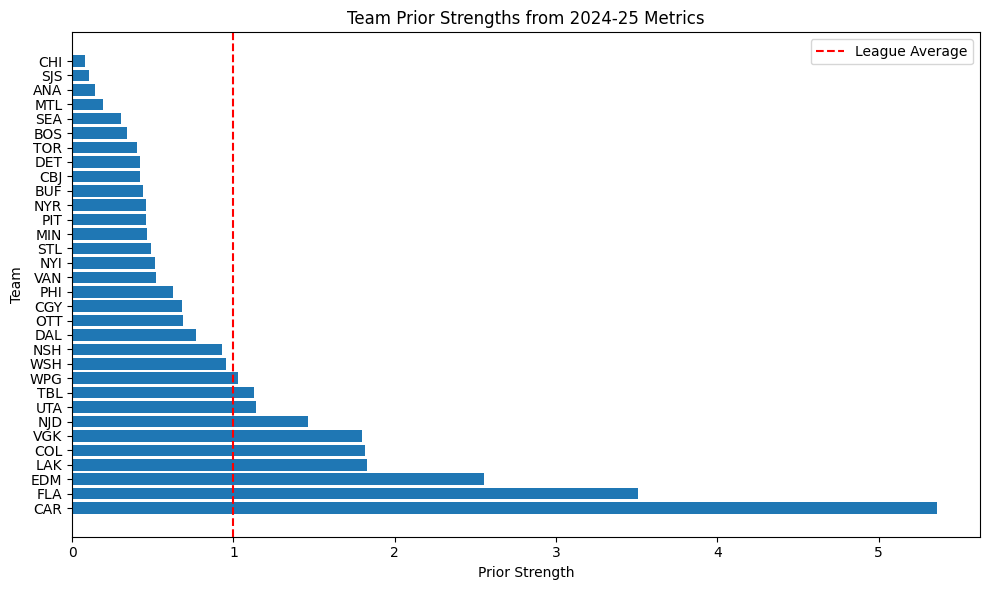

In [9]:
# Cell 9: Visualize Strengths (Optional)
import matplotlib.pyplot as plt

strengths_df = calculator.get_all_strengths()
plt.figure(figsize=(10, 6))
plt.barh(strengths_df['team'], strengths_df['prior_strength'])
plt.xlabel('Prior Strength')
plt.ylabel('Team')
plt.title('Team Prior Strengths from 2024-25 Metrics')
plt.axvline(x=1.0, color='r', linestyle='--', label='League Average')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Cell 10: Imports for Bradley-Terry
from scipy.optimize import minimize

In [11]:
class BradleyTerryModel:
    """
    Component 1B: Calculate team strengths from actual game results.
    Uses maximum likelihood estimation on win/loss outcomes.
    """
    
    def __init__(self):
        self.team_strengths = {}
        self.teams = []
        self.team_records = {}  # Store W-L records
        
    def fit(self, games_df):
        """
        Fit Bradley-Terry model on game results.
        
        Parameters:
        - games_df: DataFrame with game results
          Expected columns: team, opposingTeam, goalsFor, goalsAgainst
          Each game should have 2 rows (one for each team)
        """
        
        # Get unique teams
        self.teams = sorted(list(set(games_df['team'])))
        n_teams = len(self.teams)
        team_to_idx = {team: i for i, team in enumerate(self.teams)}
        
        # Initialize win/loss tracking
        wins = np.zeros(n_teams)
        games_played = np.zeros((n_teams, n_teams))
        
        # Track records for display
        for team in self.teams:
            self.team_records[team] = {'W': 0, 'L': 0, 'T': 0}
        
        # Process games - each game has 2 rows, process each unique game once
        processed_games = set()
        
        for _, row in games_df.iterrows():
            game_id = row['gameId']
            
            # Only process each game once
            if game_id in processed_games:
                continue
            processed_games.add(game_id)
            
            team = row['team']
            opponent = row['opposingTeam']
            goals_for = row['goalsFor']
            goals_against = row['goalsAgainst']
            
            team_idx = team_to_idx[team]
            opp_idx = team_to_idx[opponent]
            
            # Record that these teams played each other
            games_played[team_idx, opp_idx] += 1
            games_played[opp_idx, team_idx] += 1
            
            # Determine winner and update records
            if goals_for > goals_against:
                # Team won
                wins[team_idx] += 1
                self.team_records[team]['W'] += 1
                self.team_records[opponent]['L'] += 1
            elif goals_against > goals_for:
                # Opponent won
                wins[opp_idx] += 1
                self.team_records[team]['L'] += 1
                self.team_records[opponent]['W'] += 1
            else:
                # Tie - count as 0.5 wins each
                wins[team_idx] += 0.5
                wins[opp_idx] += 0.5
                self.team_records[team]['T'] += 1
                self.team_records[opponent]['T'] += 1
        
        # Maximum likelihood estimation for Bradley-Terry
        def neg_log_likelihood(log_strengths):
            """Negative log-likelihood for Bradley-Terry model"""
            strengths = np.exp(log_strengths)  # Use exp to ensure positive
            ll = 0
            
            for i in range(n_teams):
                for j in range(n_teams):
                    if i != j and games_played[i, j] > 0:
                        # Probability that team i beats team j
                        p_ij = strengths[i] / (strengths[i] + strengths[j])
                        # Log-likelihood contribution
                        # wins[i] in games against j, losses are implicitly handled
                        wins_ij = wins[i] * (games_played[i, j] / games_played[i, :].sum())
                        ll += wins_ij * np.log(p_ij + 1e-10)
            
            return -ll
        
        # Simpler approach: use win percentage as basis for optimization
        def neg_log_likelihood_simple(log_strengths):
            """Simplified negative log-likelihood"""
            strengths = np.exp(log_strengths)
            ll = 0
            
            # For each team pair that played
            for i in range(n_teams):
                team_games = games_played[i, :].sum()
                if team_games > 0:
                    # Expected wins based on strengths
                    for j in range(n_teams):
                        if games_played[i, j] > 0:
                            p_ij = strengths[i] / (strengths[i] + strengths[j])
                            # Actual win proportion against this opponent
                            actual_wins = wins[i] / team_games * games_played[i, j]
                            ll += actual_wins * np.log(p_ij + 1e-10)
                            ll += (games_played[i, j] - actual_wins) * np.log(1 - p_ij + 1e-10)
            
            return -ll
        
        # Initial guess: log(win_rate)
        initial_strengths = np.zeros(n_teams)
        for i, team in enumerate(self.teams):
            team_games = games_played[i, :].sum()
            if team_games > 0:
                win_rate = max(0.01, min(0.99, wins[i] / team_games))
                initial_strengths[i] = np.log(win_rate / (1 - win_rate))
        
        # Optimize
        result = minimize(neg_log_likelihood, initial_strengths, method='BFGS')
        
        # Convert to actual strengths
        raw_strengths = np.exp(result.x)
        
        # Normalize so average = 1.0
        raw_strengths = raw_strengths / np.mean(raw_strengths)
        
        self.team_strengths = {
            team: raw_strengths[i] 
            for i, team in enumerate(self.teams)
        }
        
        return self
    
    def get_team_strength(self, team):
        """Get Bradley-Terry strength for a specific team"""
        if team not in self.team_strengths:
            raise ValueError(f"Team '{team}' not found")
        return self.team_strengths[team]
    
    def get_all_strengths(self):
        """Get all team strengths as a sorted DataFrame"""
        df = pd.DataFrame([
            {
                'team': team, 
                'bt_strength': strength,
                'wins': self.team_records[team]['W'],
                'losses': self.team_records[team]['L'],
                'ties': self.team_records[team]['T']
            }
            for team, strength in self.team_strengths.items()
        ])
        return df.sort_values('bt_strength', ascending=False).reset_index(drop=True)
    
    def predict_probability(self, team_a, team_b):
        """
        Predict probability that team_a beats team_b.
        
        Returns: probability between 0 and 1
        """
        if team_a not in self.team_strengths or team_b not in self.team_strengths:
            raise ValueError(f"Team not found in model")
        
        strength_a = self.team_strengths[team_a]
        strength_b = self.team_strengths[team_b]
        
        # Bradley-Terry probability formula
        prob_a_wins = strength_a / (strength_a + strength_b)
        
        return prob_a_wins


In [12]:
# Cell 12: Load Game Data from SQL (with advanced metrics)
query_games = """
    SELECT 
        gameId,
        season,
        team,
        opposingTeam,
        goalsFor,
        goalsAgainst,
        home_or_away,
        gameDate,
        xGoalsFor,
        xGoalsAgainst,
        corsiPercentage,
        shotsOnGoalFor,
        shotsOnGoalAgainst,
        scoreAdjustedShotsAttemptsFor,
        scoreAdjustedShotsAttemptsAgainst,
        highDangerxGoalsFor,
        highDangerxGoalsAgainst
    FROM NHL_Gamelog
    WHERE situation = 'all'
    AND position = 'Team Level'
    AND playoffGame = 0
    AND season IN (2024, 2025)
"""

games_df = pd.read_sql(query_games, engine)

print(f"Loaded {len(games_df)} game records")
print(f"Unique games: {games_df['gameId'].nunique()}")
print(f"Date range: {games_df['gameDate'].min()} to {games_df['gameDate'].max()}")

Loaded 3910 game records
Unique games: 1955
Date range: 20241004 to 20260102


In [13]:
# Cell 13: Fit Bradley-Terry Model
bt_model = BradleyTerryModel()
bt_model.fit(games_df)

print("Bradley-Terry model fitted successfully!")

Bradley-Terry model fitted successfully!


In [14]:

# Cell 14: View Bradley-Terry Results
print("\nTeam Strengths from Actual Results (Bradley-Terry):")
bt_strengths = bt_model.get_all_strengths()
display(bt_strengths)


Team Strengths from Actual Results (Bradley-Terry):


,team,bt_strength,wins,losses,ties
0,COL,1.322260,74,35,12
1,DAL,1.219464,70,43,10
2,WSH,1.211330,70,44,9
3,TOR,1.180282,70,48,4
4,VGK,1.173508,65,44,12
5,CAR,1.172086,67,46,9
6,TBL,1.172083,68,47,7
7,WPG,1.165242,68,48,5
8,EDM,1.130036,68,52,3
9,MIN,1.120923,64,49,11


In [15]:
# Cell 15: Compare a Few Teams
print("\nSample Predictions:")
print(f"TOR vs BOS: {bt_model.predict_probability('TOR', 'BOS'):.1%} chance TOR wins")
print(f"VGK vs COL: {bt_model.predict_probability('VGK', 'COL'):.1%} chance VGK wins")


Sample Predictions:
TOR vs BOS: 57.3% chance TOR wins
VGK vs COL: 47.0% chance VGK wins


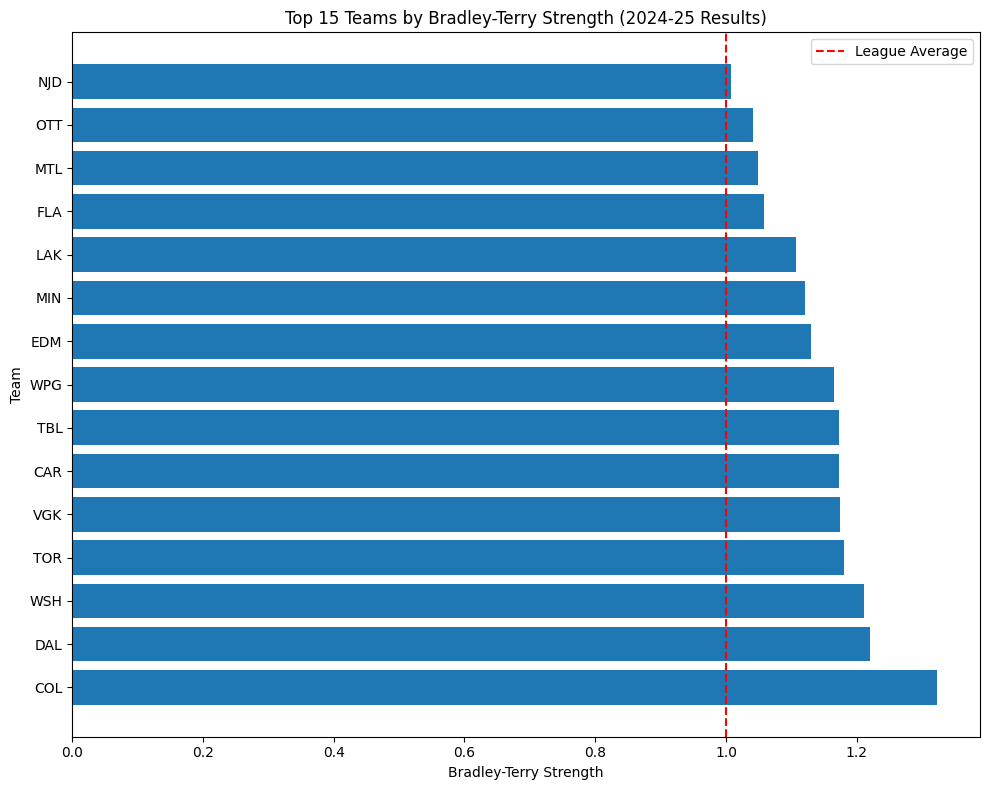

In [16]:
# Cell 16: Visualize Bradley-Terry Strengths
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
bt_strengths_sorted = bt_model.get_all_strengths().head(15)  # Top 15 teams

ax.barh(bt_strengths_sorted['team'], bt_strengths_sorted['bt_strength'])
ax.set_xlabel('Bradley-Terry Strength')
ax.set_ylabel('Team')
ax.set_title('Top 15 Teams by Bradley-Terry Strength (2024-25 Results)')
ax.axvline(x=1.0, color='r', linestyle='--', label='League Average')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Cell 17: Hybrid Blender Class
class HybridModel:
    """
    Component 1C: Blend prior strengths (metrics) with Bradley-Terry strengths (results).
    Creates a hybrid team strength rating.
    """
    
    def __init__(self, prior_calculator, bt_model, prior_weight=0.4, bt_weight=0.6):
        """
        Initialize hybrid model.
        
        Parameters:
        - prior_calculator: PriorStrengthCalculator instance
        - bt_model: BradleyTerryModel instance
        - prior_weight: Weight for prior strengths (metrics)
        - bt_weight: Weight for Bradley-Terry strengths (results)
        
        Default: 40% metrics, 60% results
        """
        self.prior_calc = prior_calculator
        self.bt_model = bt_model
        self.prior_weight = prior_weight
        self.bt_weight = bt_weight
        self.hybrid_strengths = {}
        
        # Validate weights sum to 1
        if abs(prior_weight + bt_weight - 1.0) > 0.001:
            raise ValueError("Weights must sum to 1.0")
        
        self._calculate_hybrid_strengths()
    
    def _calculate_hybrid_strengths(self):
        """Calculate blended strengths for all teams"""
        # Get all teams (use BT model as source of truth for current teams)
        teams = self.bt_model.teams
        
        for team in teams:
            # Get prior strength (from metrics) - use league average if not found
            try:
                prior_str = self.prior_calc.get_team_strength(team)
            except ValueError:
                print(f"Warning: {team} not found in prior model, using league average (1.0)")
                prior_str = 1.0
            
            # Get BT strength (from results)
            bt_str = self.bt_model.get_team_strength(team)
            
            # Blend using weights
            hybrid_str = (self.prior_weight * prior_str + 
                         self.bt_weight * bt_str)
            
            self.hybrid_strengths[team] = hybrid_str
        
        # Normalize so average = 1.0
        avg_strength = np.mean(list(self.hybrid_strengths.values()))
        self.hybrid_strengths = {
            team: strength / avg_strength 
            for team, strength in self.hybrid_strengths.items()
        }
    
    def get_team_strength(self, team):
        """Get hybrid strength for a specific team"""
        if team not in self.hybrid_strengths:
            raise ValueError(f"Team '{team}' not found")
        return self.hybrid_strengths[team]
    
    def get_all_strengths(self):
        """Get all team strengths with component breakdown"""
        results = []
        
        for team in self.hybrid_strengths.keys():
            # Get prior strength (use 1.0 if not found)
            try:
                prior_str = self.prior_calc.get_team_strength(team)
            except ValueError:
                prior_str = 1.0
            
            # Get BT strength
            bt_str = self.bt_model.get_team_strength(team)
            
            # Get hybrid strength
            hybrid_str = self.hybrid_strengths[team]
            
            results.append({
                'team': team,
                'hybrid_strength': hybrid_str,
                'prior_strength': prior_str,
                'bt_strength': bt_str,
                'wins': self.bt_model.team_records[team]['W'],
                'losses': self.bt_model.team_records[team]['L']
            })
        
        df = pd.DataFrame(results)
        return df.sort_values('hybrid_strength', ascending=False).reset_index(drop=True)
    
    def predict_game(self, home_team, away_team, home_advantage=1.0):
        """
        Predict outcome of a game.
        
        Parameters:
        - home_team: Home team abbreviation
        - away_team: Away team abbreviation
        - home_advantage: Multiplier for home team strength (default 1.0 = no advantage)
        
        Returns: Dictionary with probabilities and expected goal differential
        """
        if home_team not in self.hybrid_strengths or away_team not in self.hybrid_strengths:
            raise ValueError(f"Team not found in model")
        
        # Get hybrid strengths
        home_str = self.hybrid_strengths[home_team] * home_advantage
        away_str = self.hybrid_strengths[away_team]
        
        # Bradley-Terry probability formula
        home_win_prob = home_str / (home_str + away_str)
        away_win_prob = 1 - home_win_prob
        
        return {
            'home_team': home_team,
            'away_team': away_team,
            'home_win_prob': home_win_prob,
            'away_win_prob': away_win_prob,
            'home_advantage_applied': home_advantage
        }
    
    def update_weights(self, prior_weight, bt_weight):
        """Update the blending weights and recalculate"""
        if abs(prior_weight + bt_weight - 1.0) > 0.001:
            raise ValueError("Weights must sum to 1.0")
        
        self.prior_weight = prior_weight
        self.bt_weight = bt_weight
        self._calculate_hybrid_strengths()
        
        print(f"Weights updated: {prior_weight:.0%} prior, {bt_weight:.0%} BT")

In [18]:
# Cell 18: Create Hybrid Model
# Start with 40% metrics, 60% results
hybrid_model = HybridModel(
    prior_calculator=calculator,
    bt_model=bt_model,
    prior_weight=0.4,
    bt_weight=0.6
)

print("Hybrid model created!")
print(f"Weights: {hybrid_model.prior_weight:.0%} metrics, {hybrid_model.bt_weight:.0%} results")


Hybrid model created!
Weights: 40% metrics, 60% results


In [19]:
# Cell 19: View Hybrid Strengths
print("\nHybrid Team Strengths:")
hybrid_strengths = hybrid_model.get_all_strengths()
display(hybrid_strengths)


Hybrid Team Strengths:


,team,hybrid_strength,prior_strength,bt_strength,wins,losses
0,CAR,2.847364,5.360281,1.172086,67,46
1,FLA,2.038443,3.510106,1.057334,60,53
2,EDM,1.698813,2.551979,1.130036,68,52
3,COL,1.518355,1.812497,1.322260,74,35
4,VGK,1.423831,1.799315,1.173508,65,44
5,LAK,1.395477,1.827602,1.107393,62,49
6,NJD,1.189837,1.462358,1.008156,58,57
7,TBL,1.153071,1.124552,1.172083,68,47
8,WPG,1.109307,1.025406,1.165242,68,48
9,WSH,1.108225,0.953569,1.211330,70,44


In [20]:
# Cell 20: Compare All Three Models Side-by-Side
print("\nTop 10 Teams - Comparison Across Models:")
comparison = hybrid_strengths[['team', 'hybrid_strength', 'prior_strength', 'bt_strength', 'wins', 'losses']].head(10)
display(comparison)


Top 10 Teams - Comparison Across Models:


,team,hybrid_strength,prior_strength,bt_strength,wins,losses
0,CAR,2.847364,5.360281,1.172086,67,46
1,FLA,2.038443,3.510106,1.057334,60,53
2,EDM,1.698813,2.551979,1.130036,68,52
3,COL,1.518355,1.812497,1.322260,74,35
4,VGK,1.423831,1.799315,1.173508,65,44
5,LAK,1.395477,1.827602,1.107393,62,49
6,NJD,1.189837,1.462358,1.008156,58,57
7,TBL,1.153071,1.124552,1.172083,68,47
8,WPG,1.109307,1.025406,1.165242,68,48
9,WSH,1.108225,0.953569,1.211330,70,44


In [21]:
# Cell 21: Test Predictions
print("\nSample Game Predictions:")
print("-" * 60)

# Test some matchups
matchups = [
    ('TOR', 'BOS'),
    ('VGK', 'COL'),
    ('WPG', 'FLA'),
    ('EDM', 'DAL')
]

for home, away in matchups:
    pred = hybrid_model.predict_game(home, away)
    print(f"{home} (home) vs {away} (away):")
    print(f"  {home} win probability: {pred['home_win_prob']:.1%}")
    print(f"  {away} win probability: {pred['away_win_prob']:.1%}")
    print()


Sample Game Predictions:
------------------------------------------------------------
TOR (home) vs BOS (away):
  TOR win probability: 56.7%
  BOS win probability: 43.3%

VGK (home) vs COL (away):
  VGK win probability: 48.4%
  COL win probability: 51.6%

WPG (home) vs FLA (away):
  WPG win probability: 35.2%
  FLA win probability: 64.8%

EDM (home) vs DAL (away):
  EDM win probability: 62.1%
  DAL win probability: 37.9%



In [22]:
# Cell 22: Test with Home Ice Advantage
print("\nPredictions WITH Home Ice Advantage (10% boost):")
print("-" * 60)

for home, away in matchups:
    pred = hybrid_model.predict_game(home, away, home_advantage=1.05)
    print(f"{home} (home) vs {away} (away):")
    print(f"  {home} win probability: {pred['home_win_prob']:.1%}")
    print(f"  {away} win probability: {pred['away_win_prob']:.1%}")
    print()


Predictions WITH Home Ice Advantage (10% boost):
------------------------------------------------------------
TOR (home) vs BOS (away):
  TOR win probability: 57.9%
  BOS win probability: 42.1%

VGK (home) vs COL (away):
  VGK win probability: 49.6%
  COL win probability: 50.4%

WPG (home) vs FLA (away):
  WPG win probability: 36.4%
  FLA win probability: 63.6%

EDM (home) vs DAL (away):
  EDM win probability: 63.2%
  DAL win probability: 36.8%



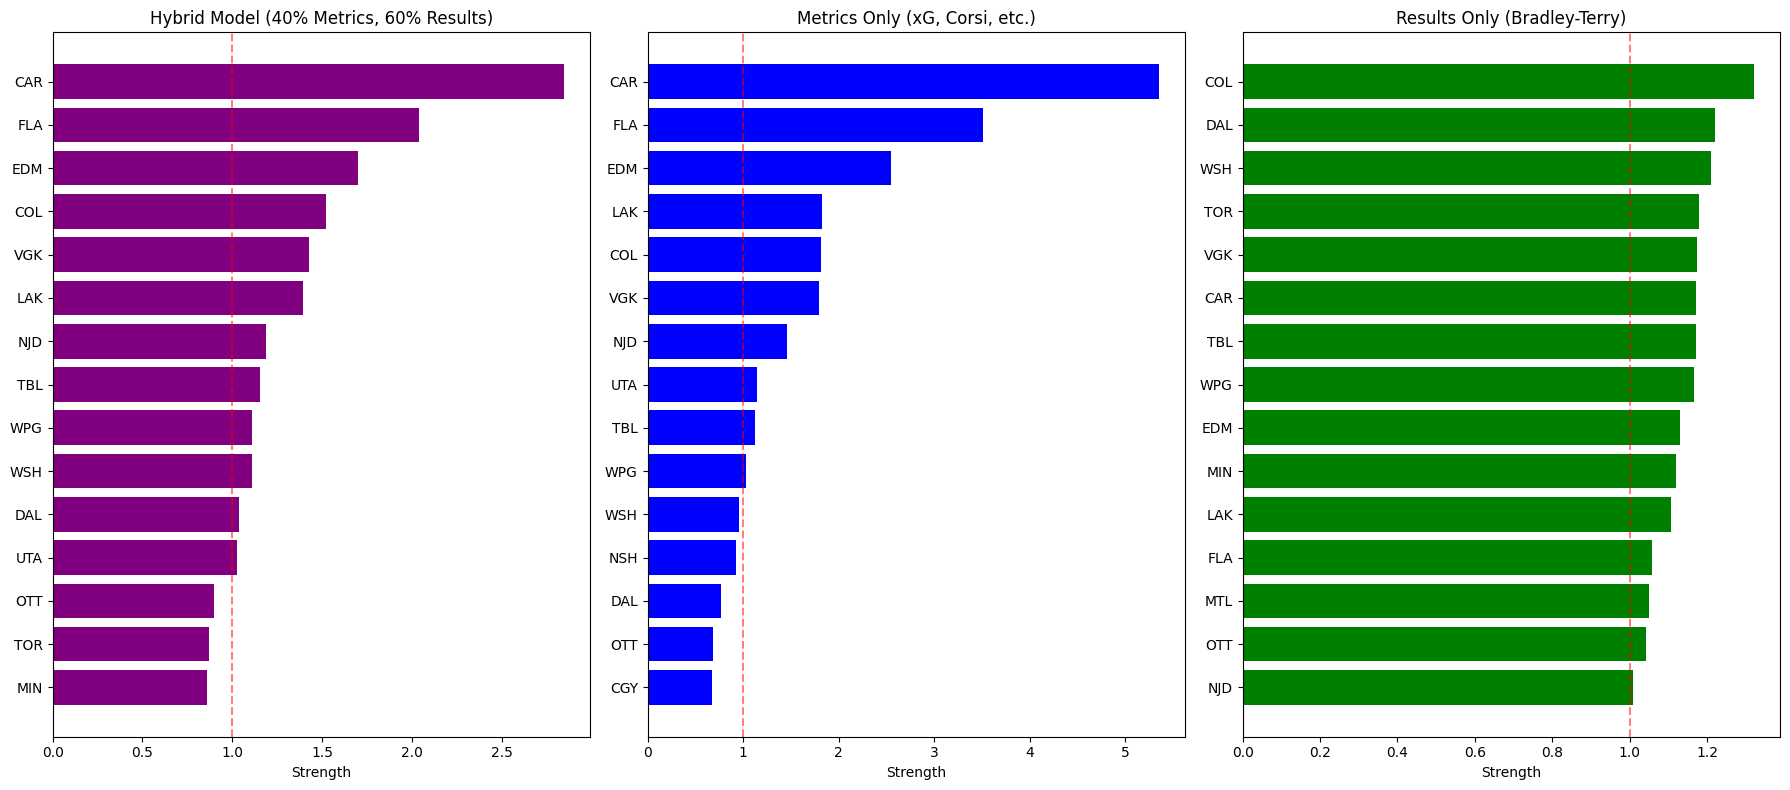

In [23]:
# Cell 23: Visualize All Three Models
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Get top 15 for each model
hybrid_top = hybrid_model.get_all_strengths().head(15)
prior_top = calculator.get_all_strengths().head(15)
bt_top = bt_model.get_all_strengths().head(15)

# Plot 1: Hybrid
axes[0].barh(hybrid_top['team'], hybrid_top['hybrid_strength'], color='purple')
axes[0].set_xlabel('Strength')
axes[0].set_title('Hybrid Model (40% Metrics, 60% Results)')
axes[0].axvline(x=1.0, color='r', linestyle='--', alpha=0.5)
axes[0].invert_yaxis()

# Plot 2: Prior (Metrics)
axes[1].barh(prior_top['team'], prior_top['prior_strength'], color='blue')
axes[1].set_xlabel('Strength')
axes[1].set_title('Metrics Only (xG, Corsi, etc.)')
axes[1].axvline(x=1.0, color='r', linestyle='--', alpha=0.5)
axes[1].invert_yaxis()

# Plot 3: Bradley-Terry (Results)
axes[2].barh(bt_top['team'], bt_top['bt_strength'], color='green')
axes[2].set_xlabel('Strength')
axes[2].set_title('Results Only (Bradley-Terry)')
axes[2].axvline(x=1.0, color='r', linestyle='--', alpha=0.5)
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

In [24]:
# Cell 24: Experiment with Different Weights
print("\nExperimenting with different weight combinations:")
print("=" * 60)

weight_combos = [
    (0.2, 0.8, "Heavy Results"),
    (0.4, 0.6, "Balanced (default)"),
    (0.5, 0.5, "Equal Weight"),
    (0.6, 0.4, "Metrics Favored"),
]

test_matchup = ('TOR', 'BOS')

for prior_w, bt_w, label in weight_combos:
    hybrid_model.update_weights(prior_w, bt_w)
    pred = hybrid_model.predict_game(test_matchup[0], test_matchup[1])
    print(f"{label} ({prior_w:.0%}/{bt_w:.0%}): {test_matchup[0]} win prob = {pred['home_win_prob']:.1%}")

# Reset to default
hybrid_model.update_weights(0.4, 0.6)
print("\nReset to default weights (40% metrics, 60% results)")


Experimenting with different weight combinations:
Weights updated: 20% prior, 80% BT
Heavy Results (20%/80%): TOR win prob = 57.1%
Weights updated: 40% prior, 60% BT
Balanced (default) (40%/60%): TOR win prob = 56.7%
Weights updated: 50% prior, 50% BT
Equal Weight (50%/50%): TOR win prob = 56.5%
Weights updated: 60% prior, 40% BT
Metrics Favored (60%/40%): TOR win prob = 56.2%
Weights updated: 40% prior, 60% BT

Reset to default weights (40% metrics, 60% results)


In [25]:

# Cell 25: Model Validation Class
class ModelValidator:
    """
    Test model performance on historical data.
    Measures accuracy, calibration, and finds optimal weights.
    """
    
    def __init__(self, games_df):
        """
        Initialize validator with game data.
        
        Parameters:
        - games_df: DataFrame with game results (same format as Bradley-Terry input)
        """
        self.games_df = games_df
        self.results = {}
    
    def evaluate_model(self, model, model_name, home_advantage=1.0):
        """
        Evaluate a model's predictions against actual outcomes.
        
        Parameters:
        - model: Model with predict_game() method (HybridModel or BradleyTerryModel)
        - model_name: Name for tracking results
        - home_advantage: Home ice advantage multiplier
        
        Returns: Dictionary with performance metrics
        """
        predictions = []
        actuals = []
        
        # Get unique games (each game appears twice in the data)
        processed_games = set()
        
        for _, row in self.games_df.iterrows():
            game_id = row['gameId']
            
            if game_id in processed_games:
                continue
            processed_games.add(game_id)
            
            # Determine home/away teams
            if row['home_or_away'] == 'HOME':
                home_team = row['team']
                away_team = row['opposingTeam']
                home_goals = row['goalsFor']
                away_goals = row['goalsAgainst']
            else:
                home_team = row['opposingTeam']
                away_team = row['team']
                home_goals = row['goalsAgainst']
                away_goals = row['goalsFor']
            
            # Skip if teams not in model
            try:
                if isinstance(model, HybridModel):
                    pred = model.predict_game(home_team, away_team, home_advantage)
                    home_win_prob = pred['home_win_prob']
                else:
                    # Bradley-Terry model
                    home_str = model.get_team_strength(home_team) * home_advantage
                    away_str = model.get_team_strength(away_team)
                    home_win_prob = home_str / (home_str + away_str)
            except (ValueError, KeyError):
                continue
            
            # Actual outcome (1 if home won, 0 if away won)
            home_won = 1 if home_goals > away_goals else 0
            
            predictions.append(home_win_prob)
            actuals.append(home_won)
        
        predictions = np.array(predictions)
        actuals = np.array(actuals)
        
        # Calculate metrics
        metrics = self._calculate_metrics(predictions, actuals)
        metrics['model_name'] = model_name
        metrics['num_games'] = len(predictions)
        
        self.results[model_name] = metrics
        
        return metrics
    
    def _calculate_metrics(self, predictions, actuals):
        """Calculate performance metrics"""
        
        # 1. Accuracy (using 50% threshold)
        predicted_winners = (predictions > 0.5).astype(int)
        accuracy = np.mean(predicted_winners == actuals)
        
        # 2. Log Loss (lower is better)
        epsilon = 1e-15
        predictions_clipped = np.clip(predictions, epsilon, 1 - epsilon)
        log_loss = -np.mean(actuals * np.log(predictions_clipped) + 
                           (1 - actuals) * np.log(1 - predictions_clipped))
        
        # 3. Brier Score (lower is better, measures calibration)
        brier_score = np.mean((predictions - actuals) ** 2)
        
        # 4. ROC AUC (higher is better, measures discrimination)
        from sklearn.metrics import roc_auc_score
        try:
            roc_auc = roc_auc_score(actuals, predictions)
        except:
            roc_auc = None
        
        # 5. Calibration by buckets
        calibration = self._calculate_calibration(predictions, actuals)
        
        return {
            'accuracy': accuracy,
            'log_loss': log_loss,
            'brier_score': brier_score,
            'roc_auc': roc_auc,
            'calibration': calibration
        }
    
    def _calculate_calibration(self, predictions, actuals, n_bins=10):
        """
        Check if predicted probabilities match actual win rates.
        Perfect calibration: if you predict 60%, team should win 60% of the time.
        """
        bins = np.linspace(0, 1, n_bins + 1)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        calibration = []
        for i in range(n_bins):
            mask = (predictions >= bins[i]) & (predictions < bins[i + 1])
            if mask.sum() > 0:
                avg_pred = predictions[mask].mean()
                avg_actual = actuals[mask].mean()
                count = mask.sum()
                calibration.append({
                    'bin_center': bin_centers[i],
                    'avg_predicted': avg_pred,
                    'avg_actual': avg_actual,
                    'count': count
                })
        
        return calibration
    
    def compare_models(self):
        """Compare all evaluated models"""
        if not self.results:
            print("No models evaluated yet!")
            return None
        
        comparison = pd.DataFrame([
            {
                'Model': name,
                'Accuracy': f"{metrics['accuracy']:.3f}",
                'Log Loss': f"{metrics['log_loss']:.4f}",
                'Brier Score': f"{metrics['brier_score']:.4f}",
                'ROC AUC': f"{metrics['roc_auc']:.3f}" if metrics['roc_auc'] else 'N/A',
                'Games': metrics['num_games']
            }
            for name, metrics in self.results.items()
        ])
        
        return comparison
    
    def plot_calibration(self, model_name):
        """Plot calibration curve for a specific model"""
        if model_name not in self.results:
            print(f"Model '{model_name}' not found!")
            return
        
        calibration = self.results[model_name]['calibration']
        
        if not calibration:
            print("No calibration data available")
            return
        
        predicted = [c['avg_predicted'] for c in calibration]
        actual = [c['avg_actual'] for c in calibration]
        counts = [c['count'] for c in calibration]
        
        plt.figure(figsize=(8, 8))
        plt.scatter(predicted, actual, s=[c*2 for c in counts], alpha=0.6)
        plt.plot([0, 1], [0, 1], 'r--', label='Perfect Calibration')
        plt.xlabel('Predicted Probability')
        plt.ylabel('Actual Win Rate')
        plt.title(f'Calibration Plot - {model_name}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

In [26]:
# Cell 26: Install sklearn if needed
try:
    from sklearn.metrics import roc_auc_score
except ImportError:
    print("Installing scikit-learn...")
    import sys
    !{sys.executable} -m pip install --user scikit-learn
    from sklearn.metrics import roc_auc_score

In [27]:
# Cell 27: Create Validator
validator = ModelValidator(games_df)
print(f"Validator created with {games_df['gameId'].nunique()} games")

Validator created with 1955 games


In [28]:
# Cell 28: Evaluate Hybrid Model
print("\nEvaluating Hybrid Model (40% metrics, 60% results)...")
hybrid_metrics = validator.evaluate_model(hybrid_model, "Hybrid (40/60)")

print(f"\nHybrid Model Performance:")
print(f"  Accuracy: {hybrid_metrics['accuracy']:.1%}")
print(f"  Log Loss: {hybrid_metrics['log_loss']:.4f}")
print(f"  Brier Score: {hybrid_metrics['brier_score']:.4f}")
print(f"  Games Evaluated: {hybrid_metrics['num_games']}")


Evaluating Hybrid Model (40% metrics, 60% results)...

Hybrid Model Performance:
  Accuracy: 56.5%
  Log Loss: 0.6859
  Brier Score: 0.2458
  Games Evaluated: 1955


In [29]:
# Cell 29: Evaluate Bradley-Terry Only
print("\nEvaluating Bradley-Terry Model (results only)...")
bt_metrics = validator.evaluate_model(bt_model, "Bradley-Terry")

print(f"\nBradley-Terry Performance:")
print(f"  Accuracy: {bt_metrics['accuracy']:.1%}")
print(f"  Log Loss: {bt_metrics['log_loss']:.4f}")
print(f"  Brier Score: {bt_metrics['brier_score']:.4f}")


Evaluating Bradley-Terry Model (results only)...

Bradley-Terry Performance:
  Accuracy: 58.2%
  Log Loss: 0.6746
  Brier Score: 0.2408


In [30]:
# Cell 30: Compare Models
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
comparison = validator.compare_models()
display(comparison)


MODEL COMPARISON


,Model,Accuracy,Log Loss,Brier Score,ROC AUC,Games
0,Hybrid (40/60),0.565,0.6859,0.2458,0.596,1955
1,Bradley-Terry,0.582,0.6746,0.2408,0.624,1955


In [31]:
# Cell 31: Test Different Weight Combinations
print("\nTesting different metric/result weight combinations...")
print("-" * 60)

weight_configs = [
    (0.0, 1.0, "Pure Results (BT)"),
    (0.2, 0.8, "Heavy Results"),
    (0.4, 0.6, "Balanced (default)"),
    (0.5, 0.5, "Equal Weight"),
    (0.6, 0.4, "Metrics Favored"),
    (0.8, 0.2, "Heavy Metrics"),
    (1.0, 0.0, "Pure Metrics")
]

weight_results = []

for prior_w, bt_w, label in weight_configs:
    if prior_w == 1.0:
        # Can't test pure metrics with current structure, skip
        continue
    
    # Create model with these weights
    test_model = HybridModel(calculator, bt_model, prior_w, bt_w)
    metrics = validator.evaluate_model(test_model, label)
    
    weight_results.append({
        'Configuration': label,
        'Prior Weight': f"{prior_w:.0%}",
        'BT Weight': f"{bt_w:.0%}",
        'Accuracy': f"{metrics['accuracy']:.3f}",
        'Log Loss': f"{metrics['log_loss']:.4f}",
        'Brier Score': f"{metrics['brier_score']:.4f}"
    })

weight_df = pd.DataFrame(weight_results)
print("\nWeight Optimization Results:")
display(weight_df)


Testing different metric/result weight combinations...
------------------------------------------------------------

Weight Optimization Results:


,Configuration,Prior Weight,BT Weight,Accuracy,Log Loss,Brier Score
0,Pure Results (BT),0%,100%,0.582,0.6746,0.2408
1,Heavy Results,20%,80%,0.578,0.6756,0.2413
2,Balanced (default),40%,60%,0.565,0.6859,0.2458
3,Equal Weight,50%,50%,0.565,0.6939,0.2490
4,Metrics Favored,60%,40%,0.562,0.7041,0.2528
5,Heavy Metrics,80%,20%,0.564,0.7338,0.2630



RECOMMENDATION

Best Accuracy: Pure Results (BT)
  Accuracy: 0.582

Best Log Loss: Pure Results (BT)
  Log Loss: 0.6746

Best Brier Score: Pure Results (BT)
  Brier Score: 0.2408

Plotting calibration curve...


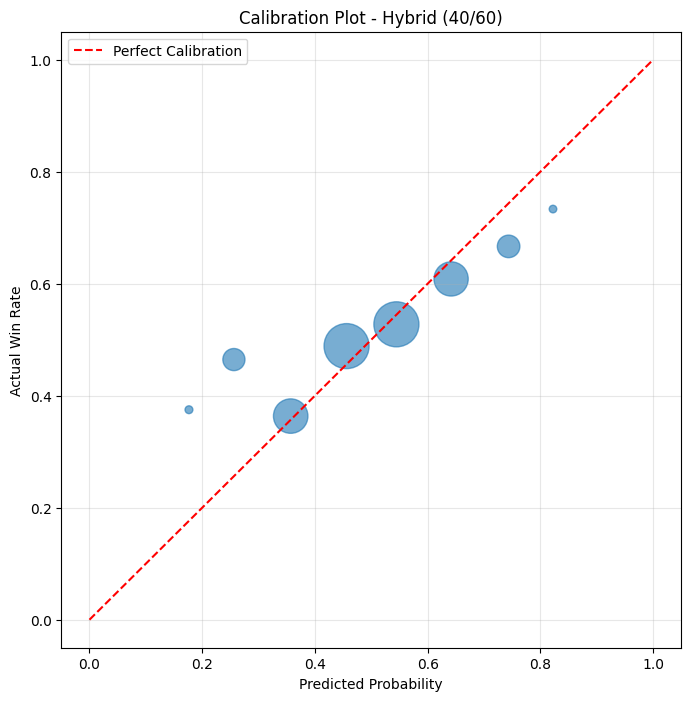

In [32]:
# Cell 32: Find Best Configuration
print("\n" + "="*60)
print("RECOMMENDATION")
print("="*60)

best_accuracy = max(weight_results, key=lambda x: float(x['Accuracy']))
best_logloss = min(weight_results, key=lambda x: float(x['Log Loss']))
best_brier = min(weight_results, key=lambda x: float(x['Brier Score']))

print(f"\nBest Accuracy: {best_accuracy['Configuration']}")
print(f"  Accuracy: {best_accuracy['Accuracy']}")

print(f"\nBest Log Loss: {best_logloss['Configuration']}")
print(f"  Log Loss: {best_logloss['Log Loss']}")

print(f"\nBest Brier Score: {best_brier['Configuration']}")
print(f"  Brier Score: {best_brier['Brier Score']}")

# Cell 33: Plot Calibration
print("\nPlotting calibration curve...")
validator.plot_calibration("Hybrid (40/60)")

In [33]:
# Cell 34: Train/Test Split Validator
class TrainTestValidator:
    """
    Proper validation with train/test split.
    Trains on early season, tests on late season games.
    """
    
    def __init__(self, games_df, test_size=0.3):
        """
        Initialize with train/test split.
        
        Parameters:
        - games_df: Full season game data
        - test_size: Fraction of games to hold out for testing (default 30%)
        """
        self.games_df = games_df
        self.test_size = test_size
        
        # Split by date
        self._create_split()
    
    def _create_split(self):
        """Split games chronologically"""
        # Get unique games sorted by date
        unique_games = self.games_df.drop_duplicates('gameId').sort_values('gameDate')
        
        # Calculate split point
        n_games = len(unique_games)
        train_size = int(n_games * (1 - self.test_size))
        
        # Get game IDs for train and test
        train_game_ids = set(unique_games.iloc[:train_size]['gameId'])
        test_game_ids = set(unique_games.iloc[train_size:]['gameId'])
        
        # Split the full dataframe
        self.train_df = self.games_df[self.games_df['gameId'].isin(train_game_ids)]
        self.test_df = self.games_df[self.games_df['gameId'].isin(test_game_ids)]
        
        print(f"Train set: {len(train_game_ids)} games ({len(self.train_df)} rows)")
        print(f"Test set: {len(test_game_ids)} games ({len(self.test_df)} rows)")
        print(f"Train date range: {self.train_df['gameDate'].min()} to {self.train_df['gameDate'].max()}")
        print(f"Test date range: {self.test_df['gameDate'].min()} to {self.test_df['gameDate'].max()}")
    
    def train_and_evaluate(self, model_name="Bradley-Terry"):
        """
        Train on train set, evaluate on test set.
        
        Returns: Dictionary with train and test metrics
        """
        # Train Bradley-Terry model on training data only
        bt_train = BradleyTerryModel()
        bt_train.fit(self.train_df)
        
        print(f"\n{model_name} model trained on {len(self.train_df['gameId'].unique())} games")
        
        # Evaluate on training set (sanity check)
        train_metrics = self._evaluate_on_data(bt_train, self.train_df, "Training")
        
        # Evaluate on test set (TRUE performance)
        test_metrics = self._evaluate_on_data(bt_train, self.test_df, "Test")
        
        return {
            'model': bt_train,
            'train_metrics': train_metrics,
            'test_metrics': test_metrics
        }
    
    def _evaluate_on_data(self, model, data_df, data_name):
        """Evaluate model on a dataset"""
        predictions = []
        actuals = []
        
        processed_games = set()
        
        for _, row in data_df.iterrows():
            game_id = row['gameId']
            
            if game_id in processed_games:
                continue
            processed_games.add(game_id)
            
            # Determine home/away
            if row['home_or_away'] == 'HOME':
                home_team = row['team']
                away_team = row['opposingTeam']
                home_goals = row['goalsFor']
                away_goals = row['goalsAgainst']
            else:
                home_team = row['opposingTeam']
                away_team = row['team']
                home_goals = row['goalsAgainst']
                away_goals = row['goalsFor']
            
            # Predict
            try:
                home_str = model.get_team_strength(home_team)
                away_str = model.get_team_strength(away_team)
                home_win_prob = home_str / (home_str + away_str)
            except (ValueError, KeyError):
                continue
            
            # Actual outcome
            home_won = 1 if home_goals > away_goals else 0
            
            predictions.append(home_win_prob)
            actuals.append(home_won)
        
        predictions = np.array(predictions)
        actuals = np.array(actuals)
        
        # Calculate metrics
        accuracy = np.mean((predictions > 0.5).astype(int) == actuals)
        
        epsilon = 1e-15
        predictions_clipped = np.clip(predictions, epsilon, 1 - epsilon)
        log_loss = -np.mean(actuals * np.log(predictions_clipped) + 
                           (1 - actuals) * np.log(1 - predictions_clipped))
        
        brier_score = np.mean((predictions - actuals) ** 2)
        
        from sklearn.metrics import roc_auc_score
        roc_auc = roc_auc_score(actuals, predictions)
        
        print(f"\n{data_name} Set Performance:")
        print(f"  Accuracy: {accuracy:.3f} ({accuracy:.1%})")
        print(f"  Log Loss: {log_loss:.4f}")
        print(f"  Brier Score: {brier_score:.4f}")
        print(f"  ROC AUC: {roc_auc:.3f}")
        print(f"  Games: {len(predictions)}")
        
        return {
            'accuracy': accuracy,
            'log_loss': log_loss,
            'brier_score': brier_score,
            'roc_auc': roc_auc,
            'n_games': len(predictions)
        }

In [34]:
# Cell 35: Create Train/Test Split (70/30)
print("Creating train/test split (70% train, 30% test)...")
print("="*60)
tt_validator = TrainTestValidator(games_df, test_size=0.3)


Creating train/test split (70% train, 30% test)...
Train set: 1368 games (2736 rows)
Test set: 587 games (1174 rows)
Train date range: 20241004 to 20251014
Test date range: 20251015 to 20260102


In [35]:
# Cell 36: Train and Evaluate
print("\n" + "="*60)
print("TRAINING AND EVALUATING MODEL")
print("="*60)

results = tt_validator.train_and_evaluate("Bradley-Terry")



TRAINING AND EVALUATING MODEL

Bradley-Terry model trained on 1368 games

Training Set Performance:
  Accuracy: 0.617 (61.7%)
  Log Loss: 0.6637
  Brier Score: 0.2355
  ROC AUC: 0.657
  Games: 1368

Test Set Performance:
  Accuracy: 0.526 (52.6%)
  Log Loss: 0.6961
  Brier Score: 0.2514
  ROC AUC: 0.532
  Games: 587


In [36]:
# Cell 37: Compare Train vs Test Performance
print("\n" + "="*60)
print("TRAIN vs TEST COMPARISON")
print("="*60)

comparison_df = pd.DataFrame([
    {
        'Dataset': 'Training',
        'Accuracy': f"{results['train_metrics']['accuracy']:.3f}",
        'Log Loss': f"{results['train_metrics']['log_loss']:.4f}",
        'Brier Score': f"{results['train_metrics']['brier_score']:.4f}",
        'ROC AUC': f"{results['train_metrics']['roc_auc']:.3f}",
        'Games': results['train_metrics']['n_games']
    },
    {
        'Dataset': 'Test (Unseen)',
        'Accuracy': f"{results['test_metrics']['accuracy']:.3f}",
        'Log Loss': f"{results['test_metrics']['log_loss']:.4f}",
        'Brier Score': f"{results['test_metrics']['brier_score']:.4f}",
        'ROC AUC': f"{results['test_metrics']['roc_auc']:.3f}",
        'Games': results['test_metrics']['n_games']
    }
])

display(comparison_df)


TRAIN vs TEST COMPARISON


,Dataset,Accuracy,Log Loss,Brier Score,ROC AUC,Games
0,Training,0.617,0.6637,0.2355,0.657,1368
1,Test (Unseen),0.526,0.6961,0.2514,0.532,587


In [37]:
# Cell 38: Analyze Overfitting
train_acc = results['train_metrics']['accuracy']
test_acc = results['test_metrics']['accuracy']
overfit_gap = train_acc - test_acc

print("\n" + "="*60)
print("OVERFITTING ANALYSIS")
print("="*60)

print(f"\nTraining Accuracy: {train_acc:.1%}")
print(f"Test Accuracy: {test_acc:.1%}")
print(f"Gap: {overfit_gap:.1%}")

if overfit_gap < 0.02:
    print("\n✅ Minimal overfitting - model generalizes well!")
elif overfit_gap < 0.05:
    print("\n⚠️  Slight overfitting - acceptable")
else:
    print("\n❌ Significant overfitting - model may be memorizing training data")

print(f"\n📊 Test accuracy of {test_acc:.1%} is your TRUE expected performance")
print("    on games the model hasn't seen before.")


OVERFITTING ANALYSIS

Training Accuracy: 61.7%
Test Accuracy: 52.6%
Gap: 9.1%

❌ Significant overfitting - model may be memorizing training data

📊 Test accuracy of 52.6% is your TRUE expected performance
    on games the model hasn't seen before.


In [38]:
# Cell 39: Save Trained Model for Feature Addition
trained_bt_model = results['model']
print("\n✅ Trained model saved as 'trained_bt_model'")
print("   Ready to add features (home ice, back-to-back, etc.)")


✅ Trained model saved as 'trained_bt_model'
   Ready to add features (home ice, back-to-back, etc.)


In [39]:
# Cell 40: Enhanced Prediction Model with Features
class EnhancedBradleyTerry:
    """
    Bradley-Terry model with situational feature adjustments:
    - Home ice advantage
    - Back-to-back game penalty
    - Rest advantage
    """
    
    def __init__(self, bt_model, games_df):
        """
        Initialize enhanced model.
        
        Parameters:
        - bt_model: Trained BradleyTerryModel
        - games_df: Game data for calculating rest/schedule info
        """
        self.bt_model = bt_model
        self.games_df = games_df
        
        # Feature parameters (we'll tune these)
        self.home_advantage = 1.08  # 8% boost for home team
        self.back_to_back_penalty = 0.90  # 10% reduction for B2B (increased from 5%)
        self.rest_advantage_per_day = 1.02  # 2% boost per extra rest day
        
        # Build team schedule info
        self._build_schedule_info()
    
    def _build_schedule_info(self):
        """Build dictionary of each team's game dates"""
        self.team_schedules = {}
        
        for team in self.bt_model.teams:
            team_games = self.games_df[
                (self.games_df['team'] == team) | 
                (self.games_df['opposingTeam'] == team)
            ].copy()
            
            # Get unique game dates for this team
            dates = sorted(team_games['gameDate'].unique())
            self.team_schedules[team] = dates
    
    def _get_rest_days(self, team, game_date):
        """Calculate days of rest before a game - FIXED VERSION"""
        if team not in self.team_schedules:
            return 2  # Default if team not found
        
        team_dates = self.team_schedules[team]
        
        # Convert game_date to int if it's not already
        game_date = int(game_date)
        
        # Convert all team dates to int for comparison
        team_dates = [int(d) for d in team_dates]
        
        # Find previous game
        previous_games = [d for d in team_dates if d < game_date]
        
        if not previous_games:
            return 3  # Season start, assume well rested
        
        last_game = max(previous_games)
        
        # Convert to actual dates and calculate difference
        from datetime import datetime
        try:
            current = datetime.strptime(str(game_date), '%Y%m%d')
            previous = datetime.strptime(str(last_game), '%Y%m%d')
            
            # Days between games (subtract 1 because game day doesn't count as rest)
            rest_days = (current - previous).days - 1
            
            return max(0, rest_days)  # Can't be negative
        except:
            # If date parsing fails, return default
            return 2
    
    def predict_game(self, home_team, away_team, game_date=None,
                     use_home_advantage=True, use_rest_factors=True):
        """
        Predict game outcome with situational features.
        
        Parameters:
        - home_team: Home team abbreviation
        - away_team: Away team abbreviation
        - game_date: Date of game (for rest calculations)
        - use_home_advantage: Apply home ice boost
        - use_rest_factors: Apply back-to-back and rest adjustments
        
        Returns: Dictionary with prediction details
        """
        # Get base strengths
        home_base = self.bt_model.get_team_strength(home_team)
        away_base = self.bt_model.get_team_strength(away_team)
        
        # Start with base strengths
        home_adjusted = home_base
        away_adjusted = away_base
        
        adjustments = {
            'home_advantage': 1.0,
            'home_rest_factor': 1.0,
            'away_rest_factor': 1.0
        }
        
        # Apply home ice advantage
        if use_home_advantage:
            home_adjusted *= self.home_advantage
            adjustments['home_advantage'] = self.home_advantage
        
        # Apply rest factors
        if use_rest_factors and game_date:
            home_rest = self._get_rest_days(home_team, game_date)
            away_rest = self._get_rest_days(away_team, game_date)
            
            # Back to back penalty
            if home_rest == 0:
                home_adjusted *= self.back_to_back_penalty
                adjustments['home_rest_factor'] = self.back_to_back_penalty
            
            if away_rest == 0:
                away_adjusted *= self.back_to_back_penalty
                adjustments['away_rest_factor'] = self.back_to_back_penalty
            
            # Rest advantage (if one team has more rest)
            rest_diff = home_rest - away_rest
            if rest_diff > 0:
                home_adjusted *= (self.rest_advantage_per_day ** rest_diff)
                adjustments['home_rest_factor'] = (self.rest_advantage_per_day ** rest_diff)
            elif rest_diff < 0:
                away_adjusted *= (self.rest_advantage_per_day ** abs(rest_diff))
                adjustments['away_rest_factor'] = (self.rest_advantage_per_day ** abs(rest_diff))
        
        # Calculate probabilities
        home_win_prob = home_adjusted / (home_adjusted + away_adjusted)
        
        return {
            'home_team': home_team,
            'away_team': away_team,
            'home_win_prob': home_win_prob,
            'away_win_prob': 1 - home_win_prob,
            'home_base_strength': home_base,
            'away_base_strength': away_base,
            'home_adjusted_strength': home_adjusted,
            'away_adjusted_strength': away_adjusted,
            'adjustments': adjustments,
            'home_rest_days': self._get_rest_days(home_team, game_date) if game_date else None,
            'away_rest_days': self._get_rest_days(away_team, game_date) if game_date else None
        }
    
    def evaluate_features(self, test_df):
        """
        Evaluate model with different feature combinations on test set.
        """
        results = {}
        
        # Test different configurations
        configs = [
            ('Base (no features)', False, False),
            ('Home Ice Only', True, False),
            ('Rest Only', False, True),
            ('All Features', True, True)
        ]
        
        for config_name, use_home, use_rest in configs:
            predictions = []
            actuals = []
            
            processed_games = set()
            
            for _, row in test_df.iterrows():
                game_id = row['gameId']
                
                if game_id in processed_games:
                    continue
                processed_games.add(game_id)
                
                # Determine teams
                if row['home_or_away'] == 'HOME':
                    home_team = row['team']
                    away_team = row['opposingTeam']
                    home_goals = row['goalsFor']
                    away_goals = row['goalsAgainst']
                else:
                    home_team = row['opposingTeam']
                    away_team = row['team']
                    home_goals = row['goalsAgainst']
                    away_goals = row['goalsFor']
                
                game_date = row['gameDate']
                
                # Predict
                try:
                    pred = self.predict_game(
                        home_team, away_team, game_date,
                        use_home_advantage=use_home,
                        use_rest_factors=use_rest
                    )
                    home_win_prob = pred['home_win_prob']
                except (ValueError, KeyError):
                    continue
                
                home_won = 1 if home_goals > away_goals else 0
                
                predictions.append(home_win_prob)
                actuals.append(home_won)
            
            predictions = np.array(predictions)
            actuals = np.array(actuals)
            
            # Calculate metrics
            accuracy = np.mean((predictions > 0.5).astype(int) == actuals)
            
            epsilon = 1e-15
            predictions_clipped = np.clip(predictions, epsilon, 1 - epsilon)
            log_loss = -np.mean(actuals * np.log(predictions_clipped) + 
                               (1 - actuals) * np.log(1 - predictions_clipped))
            
            brier_score = np.mean((predictions - actuals) ** 2)
            
            results[config_name] = {
                'accuracy': accuracy,
                'log_loss': log_loss,
                'brier_score': brier_score,
                'n_games': len(predictions)
            }
        
        return results

In [40]:
# Cell 41: Create Enhanced Model (FIXED)
print("Creating enhanced model with features...")
enhanced_model = EnhancedBradleyTerry(trained_bt_model, games_df)  # Changed from tt_validator.train_df

print(f"\n✅ Enhanced model created with:")
print(f"   - Home ice advantage: {enhanced_model.home_advantage:.1%} boost")
print(f"   - Back-to-back penalty: {enhanced_model.back_to_back_penalty:.1%} of strength")
print(f"   - Rest advantage: {enhanced_model.rest_advantage_per_day:.1%} per extra day")


Creating enhanced model with features...

✅ Enhanced model created with:
   - Home ice advantage: 108.0% boost
   - Back-to-back penalty: 90.0% of strength
   - Rest advantage: 102.0% per extra day


In [41]:
# Cell 42: Test Sample Predictions
print("\n" + "="*60)
print("SAMPLE PREDICTIONS WITH FEATURES")
print("="*60)

# Get a sample game date from test set
sample_date = tt_validator.test_df['gameDate'].iloc[0]

sample_matchups = [
    ('TOR', 'BOS'),
    ('VGK', 'COL'),
    ('WPG', 'EDM')
]

for home, away in sample_matchups:
    pred = enhanced_model.predict_game(home, away, sample_date, 
                                       use_home_advantage=True, 
                                       use_rest_factors=True)
    
    print(f"\n{home} (home) vs {away} (away):")
    print(f"  Win Probability: {home} {pred['home_win_prob']:.1%} | {away} {pred['away_win_prob']:.1%}")
    print(f"  Base Strengths: {pred['home_base_strength']:.3f} | {pred['away_base_strength']:.3f}")
    print(f"  Adjusted: {pred['home_adjusted_strength']:.3f} | {pred['away_adjusted_strength']:.3f}")
    if pred['home_rest_days'] is not None:
        print(f"  Rest Days: {pred['home_rest_days']} | {pred['away_rest_days']}")



SAMPLE PREDICTIONS WITH FEATURES

TOR (home) vs BOS (away):
  Win Probability: TOR 61.7% | BOS 38.3%
  Base Strengths: 1.268 | 0.849
  Adjusted: 1.369 | 0.849
  Rest Days: 1 | 1

VGK (home) vs COL (away):
  Win Probability: VGK 53.1% | COL 46.9%
  Base Strengths: 1.268 | 1.209
  Adjusted: 1.369 | 1.209
  Rest Days: 1 | 1

WPG (home) vs EDM (away):
  Win Probability: WPG 54.9% | EDM 45.1%
  Base Strengths: 1.353 | 1.200
  Adjusted: 1.461 | 1.200
  Rest Days: 1 | 1


In [42]:
# Cell 43: Evaluate Feature Impact
print("\n" + "="*60)
print("EVALUATING FEATURE IMPACT ON TEST SET")
print("="*60)

feature_results = enhanced_model.evaluate_features(tt_validator.test_df)

feature_comparison = pd.DataFrame([
    {
        'Configuration': config,
        'Accuracy': f"{metrics['accuracy']:.3f} ({metrics['accuracy']:.1%})",
        'Log Loss': f"{metrics['log_loss']:.4f}",
        'Brier Score': f"{metrics['brier_score']:.4f}",
        'Games': metrics['n_games']
    }
    for config, metrics in feature_results.items()
])

display(feature_comparison)


EVALUATING FEATURE IMPACT ON TEST SET


,Configuration,Accuracy,Log Loss,Brier Score,Games
0,Base (no features),0.526 (52.6%),0.6961,0.2514,587
1,Home Ice Only,0.508 (50.8%),0.6993,0.2529,587
2,Rest Only,0.545 (54.5%),0.6935,0.2501,587
3,All Features,0.514 (51.4%),0.6969,0.2518,587


In [43]:

# Cell 44: Feature Impact Analysis
print("\n" + "="*60)
print("FEATURE IMPACT ANALYSIS")
print("="*60)

base_acc = feature_results['Base (no features)']['accuracy']
home_acc = feature_results['Home Ice Only']['accuracy']
rest_acc = feature_results['Rest Only']['accuracy']
all_acc = feature_results['All Features']['accuracy']

print(f"\nBaseline (no features): {base_acc:.1%}")
print(f"+ Home Ice Advantage:   {home_acc:.1%} ({(home_acc - base_acc)*100:+.1f} pts)")
print(f"+ Rest Factors:         {rest_acc:.1%} ({(rest_acc - base_acc)*100:+.1f} pts)")
print(f"+ All Features:         {all_acc:.1%} ({(all_acc - base_acc)*100:+.1f} pts)")

if all_acc > base_acc:
    print(f"\n✅ Features improved accuracy by {(all_acc - base_acc)*100:.1f} percentage points!")
else:
    print(f"\n⚠️  Features didn't improve accuracy. May need tuning.")

print(f"\n📊 Best configuration: ", end="")
best_config = max(feature_results.items(), key=lambda x: x[1]['accuracy'])
print(f"{best_config[0]} at {best_config[1]['accuracy']:.1%}")


FEATURE IMPACT ANALYSIS

Baseline (no features): 52.6%
+ Home Ice Advantage:   50.8% (-1.9 pts)
+ Rest Factors:         54.5% (+1.9 pts)
+ All Features:         51.4% (-1.2 pts)

⚠️  Features didn't improve accuracy. May need tuning.

📊 Best configuration: Rest Only at 54.5%


In [44]:
# Verify the fix
sample_games = tt_validator.test_df.head(20)
for _, row in sample_games.iterrows():
    team = row['team']
    date = row['gameDate']
    rest = enhanced_model._get_rest_days(team, date)
    print(f"{team} on {date}: {rest} rest days")

NYR on 20251115: 2 rest days
NYR on 20251116: 0 rest days
NYR on 20251129: 0 rest days
NYR on 20251118: 1 rest days
NYR on 20251120: 1 rest days
NYR on 20251122: 1 rest days
NYR on 20251124: 1 rest days
NYR on 20251202: 2 rest days
NYR on 20251204: 1 rest days
NYR on 20251126: 1 rest days
NYR on 20251128: 1 rest days
SJS on 20251026: 1 rest days
NYR on 20251206: 1 rest days
SJS on 20251028: 1 rest days
SJS on 20251030: 1 rest days
SJS on 20251101: 1 rest days
SJS on 20251102: 0 rest days
SJS on 20251105: 2 rest days
SJS on 20251107: 1 rest days
SJS on 20251108: 0 rest days


In [45]:
# Cell 47: Make a Real Prediction
def predict_todays_game(home_team, away_team, game_date=None):
    """
    Predict tonight's game with your model.
    
    Parameters:
    - home_team: Home team abbreviation (e.g., 'PIT')
    - away_team: Away team abbreviation (e.g., 'LAK')
    - game_date: Date in YYYYMMDD format (optional, uses today if None)
    """
    from datetime import datetime
    
    if game_date is None:
        game_date = int(datetime.today().strftime('%Y%m%d'))
    
    # Get prediction
    pred = enhanced_model.predict_game(
        home_team, 
        away_team, 
        game_date,
        use_home_advantage=True,
        use_rest_factors=True
    )
    
    print("="*60)
    print(f"PREDICTION: {home_team} (home) vs {away_team} (away)")
    print("="*60)
    print(f"\n📊 Win Probabilities:")
    print(f"   {home_team}: {pred['home_win_prob']:.1%}")
    print(f"   {away_team}: {pred['away_win_prob']:.1%}")
    
    print(f"\n💪 Team Strengths:")
    print(f"   {home_team} base: {pred['home_base_strength']:.3f}")
    print(f"   {away_team} base: {pred['away_base_strength']:.3f}")
    
    print(f"\n🏠 Adjustments Applied:")
    print(f"   Home advantage: {pred['adjustments']['home_advantage']:.2f}x")
    if pred['home_rest_days'] is not None:
        print(f"   {home_team} rest: {pred['home_rest_days']} days (factor: {pred['adjustments']['home_rest_factor']:.2f}x)")
        print(f"   {away_team} rest: {pred['away_rest_days']} days (factor: {pred['adjustments']['away_rest_factor']:.2f}x)")
    
    print(f"\n⚡ Final Adjusted Strengths:")
    print(f"   {home_team}: {pred['home_adjusted_strength']:.3f}")
    print(f"   {away_team}: {pred['away_adjusted_strength']:.3f}")
    
    return pred

# Example: Tonight's game
prediction = predict_todays_game('PIT', 'LAK')

PREDICTION: PIT (home) vs LAK (away)

📊 Win Probabilities:
   PIT: 45.4%
   LAK: 54.6%

💪 Team Strengths:
   PIT base: 0.895
   LAK base: 1.163

🏠 Adjustments Applied:
   Home advantage: 1.08x
   PIT rest: 1 days (factor: 1.00x)
   LAK rest: 1 days (factor: 1.00x)

⚡ Final Adjusted Strengths:
   PIT: 0.967
   LAK: 1.163


In [46]:
# Cell 48: Compare to Betting Odds
def compare_to_odds(home_team, away_team, vegas_home_ml, vegas_away_ml):
    """
    Compare your model to Vegas odds.
    
    Parameters:
    - vegas_home_ml: Vegas moneyline for home team (e.g., -150)
    - vegas_away_ml: Vegas moneyline for away team (e.g., +130)
    """
    # Get your prediction
    pred = enhanced_model.predict_game(home_team, away_team)
    your_home_prob = pred['home_win_prob']
    your_away_prob = pred['away_win_prob']
    
    # Convert Vegas odds to implied probability
    def ml_to_prob(moneyline):
        if moneyline < 0:
            return abs(moneyline) / (abs(moneyline) + 100)
        else:
            return 100 / (moneyline + 100)
    
    vegas_home_prob = ml_to_prob(vegas_home_ml)
    vegas_away_prob = ml_to_prob(vegas_away_ml)
    
    print("="*60)
    print(f"{home_team} vs {away_team} - YOUR MODEL vs VEGAS")
    print("="*60)
    
    print(f"\n{home_team} (home):")
    print(f"  Your model:  {your_home_prob:.1%}")
    print(f"  Vegas odds:  {vegas_home_prob:.1%} ({vegas_home_ml:+d})")
    print(f"  Edge:        {(your_home_prob - vegas_home_prob)*100:+.1f} points")
    
    print(f"\n{away_team} (away):")
    print(f"  Your model:  {your_away_prob:.1%}")
    print(f"  Vegas odds:  {vegas_away_prob:.1%} ({vegas_away_ml:+d})")
    print(f"  Edge:        {(your_away_prob - vegas_away_prob)*100:+.1f} points")
    
    # Betting recommendation
    print("\n💰 Betting Recommendation:")
    home_edge = your_home_prob - vegas_home_prob
    away_edge = your_away_prob - vegas_away_prob
    
    threshold = 0.05  # 5% edge threshold
    
    if home_edge > threshold:
        print(f"   ✅ BET {home_team} (You have {home_edge*100:.1f}% edge)")
    elif away_edge > threshold:
        print(f"   ✅ BET {away_team} (You have {away_edge*100:.1f}% edge)")
    else:
        print(f"   ⚠️  NO BET (No significant edge)")

# Example
compare_to_odds('PIT', 'LAK', vegas_home_ml=175, vegas_away_ml=-187)

PIT vs LAK - YOUR MODEL vs VEGAS

PIT (home):
  Your model:  45.4%
  Vegas odds:  36.4% (+175)
  Edge:        +9.0 points

LAK (away):
  Your model:  54.6%
  Vegas odds:  65.2% (-187)
  Edge:        -10.6 points

💰 Betting Recommendation:
   ✅ BET PIT (You have 9.0% edge)


In [47]:
# Cell 49: Predict Multiple Games
def predict_todays_slate(games_list):
    """
    Predict multiple games at once.
    
    Parameters:
    - games_list: List of tuples (home_team, away_team)
    """
    results = []
    
    for home, away in games_list:
        pred = enhanced_model.predict_game(home, away)
        results.append({
            'Matchup': f"{home} vs {away}",
            'Home Team': home,
            'Away Team': away,
            'Home Win %': f"{pred['home_win_prob']:.1%}",
            'Away Win %': f"{pred['away_win_prob']:.1%}",
            'Favorite': home if pred['home_win_prob'] > 0.5 else away,
            'Favorite %': f"{max(pred['home_win_prob'], pred['away_win_prob']):.1%}"
        })
    
    return pd.DataFrame(results)

# Example: Tonight's games (replace with actual games)
todays_games = [
    ('PIT', 'LAK'),
    ('TOR', 'BOS'),
    ('VGK', 'COL'),
    ('NYR', 'NYI')
]

predictions_df = predict_todays_slate(todays_games)
display(predictions_df)

,Matchup,Home Team,Away Team,Home Win %,Away Win %,Favorite,Favorite %
0,PIT vs LAK,PIT,LAK,45.4%,54.6%,LAK,54.6%
1,TOR vs BOS,TOR,BOS,61.7%,38.3%,TOR,61.7%
2,VGK vs COL,VGK,COL,53.1%,46.9%,VGK,53.1%
3,NYR vs NYI,NYR,NYI,54.6%,45.4%,NYR,54.6%


In [48]:
# Cell 50: Temporal Weight Calculator
class TemporalWeightCalculator:
    """
    Calculate how much to weight prior season vs current season
    based on games played in current season.
    """
    
    def __init__(self, decay_rate='moderate'):
        """
        Initialize weight calculator.
        
        Parameters:
        - decay_rate: How quickly to shift from prior to current
          Options: 'slow', 'moderate', 'fast'
        """
        self.decay_curves = {
            'slow': {
                0: 0.95,    # Start: 95% prior, 5% current
                10: 0.85,
                20: 0.70,
                30: 0.55,
                40: 0.40,
                50: 0.25,
                60: 0.15,
                82: 0.10    # End: 10% prior, 90% current
            },
            'moderate': {
                0: 0.90,    # Start: 90% prior, 10% current
                10: 0.75,
                20: 0.60,
                30: 0.45,
                40: 0.30,
                50: 0.20,
                60: 0.15,
                82: 0.10
            },
            'fast': {
                0: 0.80,
                10: 0.60,
                20: 0.40,
                30: 0.25,
                40: 0.15,
                50: 0.10,
                60: 0.05,
                82: 0.05
            }
        }
        
        self.decay_rate = decay_rate
        self.curve = self.decay_curves[decay_rate]
    
    def get_prior_weight(self, games_played):
        """
        Get weight for prior season based on games played in current season.
        
        Returns: (prior_weight, current_weight) as tuple
        """
        # Find the two closest points in the curve
        games_points = sorted(self.curve.keys())
        
        if games_played <= games_points[0]:
            prior_w = self.curve[games_points[0]]
        elif games_played >= games_points[-1]:
            prior_w = self.curve[games_points[-1]]
        else:
            # Linear interpolation between two points
            for i in range(len(games_points) - 1):
                if games_points[i] <= games_played < games_points[i + 1]:
                    g1, g2 = games_points[i], games_points[i + 1]
                    w1, w2 = self.curve[g1], self.curve[g2]
                    
                    # Interpolate
                    ratio = (games_played - g1) / (g2 - g1)
                    prior_w = w1 + (w2 - w1) * ratio
                    break
        
        current_w = 1 - prior_w
        return prior_w, current_w
    
    def visualize_decay(self):
        """Plot the decay curve"""
        import matplotlib.pyplot as plt
        
        games = list(range(0, 83))
        weights = [self.get_prior_weight(g) for g in games]
        prior_weights = [w[0] for w in weights]
        current_weights = [w[1] for w in weights]
        
        plt.figure(figsize=(10, 6))
        plt.plot(games, prior_weights, label='Prior Season Weight', linewidth=2)
        plt.plot(games, current_weights, label='Current Season Weight', linewidth=2)
        plt.xlabel('Games Played in Current Season')
        plt.ylabel('Weight')
        plt.title(f'Temporal Decay Curve ({self.decay_rate.capitalize()})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 82)
        plt.ylim(0, 1)
        plt.show()

In [49]:
# Cell 51: Blended Bradley-Terry Model
class BlendedBradleyTerry:
    """
    Bradley-Terry model that blends prior season with current season
    using temporal weighting.
    """
    
    def __init__(self, prior_season_df, current_season_df, weight_calculator):
        """
        Initialize blended model.
        
        Parameters:
        - prior_season_df: Games from 2024-25
        - current_season_df: Games from 2025-26
        - weight_calculator: TemporalWeightCalculator instance
        """
        self.prior_df = prior_season_df
        self.current_df = current_season_df
        self.weight_calc = weight_calculator
        
        # Train separate models
        self.prior_model = BradleyTerryModel()
        self.current_model = BradleyTerryModel()
        
        print("Training prior season model (2024-25)...")
        self.prior_model.fit(prior_season_df)
        
        if len(current_season_df) > 0:
            print(f"Training current season model (2025-26) on {len(current_season_df['gameId'].unique())} games...")
            self.current_model.fit(current_season_df)
            self.has_current_data = True
        else:
            print("No current season games yet - using prior season only")
            self.has_current_data = False
        
        # Calculate current season progress
        self.games_played = len(current_season_df['gameId'].unique())
        self.prior_weight, self.current_weight = weight_calculator.get_prior_weight(self.games_played)
        
        print(f"\n📊 Weighting: {self.prior_weight:.0%} prior season, {self.current_weight:.0%} current season")
        
        # Calculate blended strengths
        self._calculate_blended_strengths()
    
    def _calculate_blended_strengths(self):
        """Blend prior and current season strengths"""
        self.blended_strengths = {}
        
        # Get all teams (union of both seasons)
        all_teams = set(self.prior_model.teams)
        if self.has_current_data:
            all_teams = all_teams.union(set(self.current_model.teams))
        
        for team in all_teams:
            # Get prior strength (default to 1.0 if team doesn't exist)
            try:
                prior_str = self.prior_model.get_team_strength(team)
            except ValueError:
                prior_str = 1.0
            
            # Get current strength (default to 1.0 if not enough data)
            if self.has_current_data:
                try:
                    current_str = self.current_model.get_team_strength(team)
                except ValueError:
                    current_str = 1.0
            else:
                current_str = 1.0
            
            # Blend
            blended = (self.prior_weight * prior_str + 
                      self.current_weight * current_str)
            
            self.blended_strengths[team] = blended
        
        # Normalize
        avg = np.mean(list(self.blended_strengths.values()))
        self.blended_strengths = {
            team: s / avg for team, s in self.blended_strengths.items()
        }
    
    def get_team_strength(self, team):
        """Get blended strength for a team"""
        if team not in self.blended_strengths:
            raise ValueError(f"Team '{team}' not found")
        return self.blended_strengths[team]
    
    def get_all_strengths(self):
        """Get all team strengths with breakdown"""
        results = []
        
        for team in self.blended_strengths.keys():
            try:
                prior_str = self.prior_model.get_team_strength(team)
            except ValueError:
                prior_str = 1.0
            
            if self.has_current_data:
                try:
                    current_str = self.current_model.get_team_strength(team)
                    current_record = self.current_model.team_records[team]
                    wins = current_record['W']
                    losses = current_record['L']
                except (ValueError, KeyError):
                    current_str = 1.0
                    wins = 0
                    losses = 0
            else:
                current_str = 1.0
                wins = 0
                losses = 0
            
            results.append({
                'team': team,
                'blended_strength': self.blended_strengths[team],
                'prior_strength': prior_str,
                'current_strength': current_str,
                'current_wins': wins,
                'current_losses': losses
            })
        
        df = pd.DataFrame(results)
        return df.sort_values('blended_strength', ascending=False).reset_index(drop=True)
    
    def update_with_new_games(self, new_games_df):
        """
        Update model when new games are added to current season.
        
        Parameters:
        - new_games_df: Updated current season games (all games, not just new ones)
        """
        print(f"\n🔄 Updating model with new current season data...")
        
        # Retrain current season model
        self.current_df = new_games_df
        self.current_model = BradleyTerryModel()
        self.current_model.fit(new_games_df)
        self.has_current_data = True
        
        # Update weights based on new game count
        self.games_played = len(new_games_df['gameId'].unique())
        self.prior_weight, self.current_weight = self.weight_calc.get_prior_weight(self.games_played)
        
        print(f"📊 Updated weighting: {self.prior_weight:.0%} prior, {self.current_weight:.0%} current")
        print(f"   Games in current season: {self.games_played}")
        
        # Recalculate blended strengths
        self._calculate_blended_strengths()
        
        print("✅ Model updated successfully!")

Prior season (2024-25): 2624 rows, 1312 games
Current season (2025-26): 1286 rows, 643 games


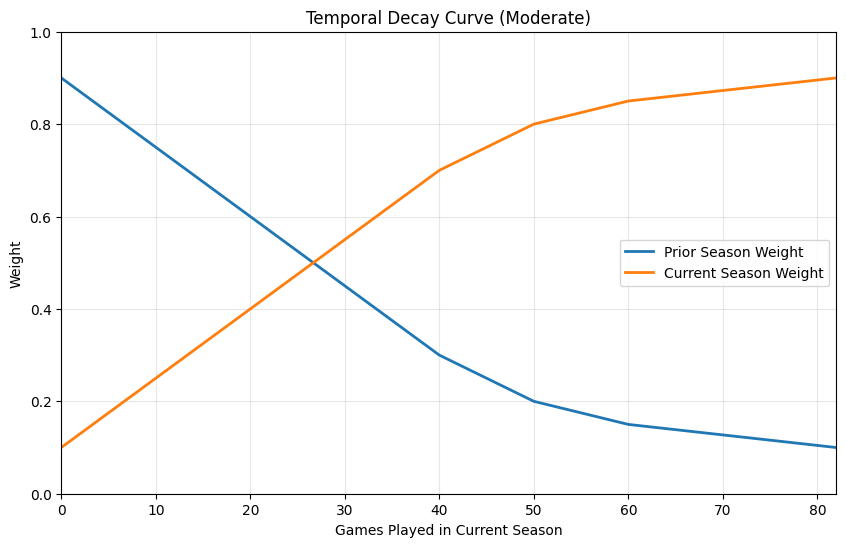

In [50]:
# Cell 52: Setup Temporal Blending
# Split your data by season
prior_season = games_df[games_df['season'] == 2024].copy()
current_season = games_df[games_df['season'] == 2025].copy()

print(f"Prior season (2024-25): {len(prior_season)} rows, {len(prior_season['gameId'].unique())} games")
print(f"Current season (2025-26): {len(current_season)} rows, {len(current_season['gameId'].unique())} games")

# Create weight calculator
weight_calc = TemporalWeightCalculator(decay_rate='moderate')

# Visualize the decay curve
weight_calc.visualize_decay()

In [51]:
# Cell 53: Create Blended Model
blended_model = BlendedBradleyTerry(prior_season, current_season, weight_calc)

Training prior season model (2024-25)...
Training current season model (2025-26) on 643 games...

📊 Weighting: 10% prior season, 90% current season


In [52]:
# Cell 54: View Blended Strengths
print("\n" + "="*60)
print("BLENDED TEAM STRENGTHS")
print("="*60)

blended_strengths = blended_model.get_all_strengths()
display(blended_strengths)


BLENDED TEAM STRENGTHS


,team,blended_strength,prior_strength,current_strength,current_wins,current_losses
0,COL,1.572373,1.182928,1.615644,29,5
1,DAL,1.219691,1.219511,1.219711,22,13
2,TBL,1.196030,1.158535,1.200196,23,15
3,MIN,1.159927,1.097561,1.166856,22,15
4,CAR,1.153461,1.182927,1.150187,20,14
5,WSH,1.135529,1.256097,1.122132,21,16
6,MTL,1.135168,0.999999,1.150187,20,14
7,DET,1.120202,0.914633,1.143043,22,16
8,NYI,1.052596,0.865853,1.073345,18,15
9,EDM,1.040393,1.182927,1.024556,20,19


In [53]:
# Cell 55: Compare Top Teams
print("\n" + "="*60)
print("TOP 10 TEAMS - PRIOR vs CURRENT vs BLENDED")
print("="*60)

top_teams = blended_strengths.head(10)[['team', 'blended_strength', 'prior_strength', 
                                         'current_strength', 'current_wins', 'current_losses']]
display(top_teams)


TOP 10 TEAMS - PRIOR vs CURRENT vs BLENDED


,team,blended_strength,prior_strength,current_strength,current_wins,current_losses
0,COL,1.572373,1.182928,1.615644,29,5
1,DAL,1.219691,1.219511,1.219711,22,13
2,TBL,1.196030,1.158535,1.200196,23,15
3,MIN,1.159927,1.097561,1.166856,22,15
4,CAR,1.153461,1.182927,1.150187,20,14
5,WSH,1.135529,1.256097,1.122132,21,16
6,MTL,1.135168,0.999999,1.150187,20,14
7,DET,1.120202,0.914633,1.143043,22,16
8,NYI,1.052596,0.865853,1.073345,18,15
9,EDM,1.040393,1.182927,1.024556,20,19


In [54]:
# Cell 56: Current Season Metric Strength Calculator
class CurrentSeasonMetricStrength:
    """
    Calculate team strengths from current season advanced metrics.
    Uses game-level xG, Corsi, etc. when W/L sample is too small.
    """
    
    def __init__(self, current_season_df, metric_weights=None):
        """
        Calculate metric-based strengths for current season.
        
        Parameters:
        - current_season_df: Current season game data with advanced metrics
        - metric_weights: Dict of metric weights (same as Component 1A)
        """
        if metric_weights is None:
            # Use same weights as before
            self.weights = {
                'xgoals_diff': 0.35,
                'corsi_pct': 0.25,
                'shots_diff': 0.20,
                'score_adj_xg_diff': 0.10,
                'hd_diff': 0.10
            }
        else:
            self.weights = metric_weights
        
        self.current_df = current_season_df
        self.metric_strengths = {}
        
        if len(current_season_df) > 0:
            self._calculate_metric_strengths()
    
    def _calculate_metric_strengths(self):
        """Calculate team strengths from game-level metrics"""
        # Aggregate metrics by team
        team_metrics = {}
        
        for team in self.current_df['team'].unique():
            team_games = self.current_df[self.current_df['team'] == team]
            
            n_games = len(team_games)
            
            # Calculate average metrics per game
            xg_for = team_games['xGoalsFor'].sum() / n_games
            xg_against = team_games['xGoalsAgainst'].sum() / n_games
            xg_diff = xg_for - xg_against
            
            corsi_pct = team_games['corsiPercentage'].mean() - 0.50
            
            shots_for = team_games['shotsOnGoalFor'].sum() / n_games
            shots_against = team_games['shotsOnGoalAgainst'].sum() / n_games
            shots_diff = shots_for - shots_against
            
            score_adj_for = team_games['scoreAdjustedShotsAttemptsFor'].sum() / n_games
            score_adj_against = team_games['scoreAdjustedShotsAttemptsAgainst'].sum() / n_games
            score_adj_diff = score_adj_for - score_adj_against
            
            hd_xg_for = team_games['highDangerxGoalsFor'].sum() / n_games
            hd_xg_against = team_games['highDangerxGoalsAgainst'].sum() / n_games
            hd_diff = hd_xg_for - hd_xg_against
            
            team_metrics[team] = {
                'xg_diff': xg_diff,
                'corsi_pct': corsi_pct,
                'shots_diff': shots_diff,
                'score_adj_diff': score_adj_diff,
                'hd_diff': hd_diff,
                'games': n_games
            }
        
        # Convert to DataFrame for normalization
        metrics_df = pd.DataFrame([
            {
                'team': team,
                'xg_diff': m['xg_diff'],
                'corsi_pct': m['corsi_pct'],
                'shots_diff': m['shots_diff'],
                'score_adj_diff': m['score_adj_diff'],
                'hd_diff': m['hd_diff']
            }
            for team, m in team_metrics.items()
        ])
        
        # Normalize to z-scores
        normalized = pd.DataFrame()
        normalized['team'] = metrics_df['team']
        
        for metric in ['xg_diff', 'corsi_pct', 'shots_diff', 'score_adj_diff', 'hd_diff']:
            mean = metrics_df[metric].mean()
            std = metrics_df[metric].std()
            if std > 0:
                normalized[metric] = (metrics_df[metric] - mean) / std
            else:
                normalized[metric] = 0
        
        # Calculate composite scores
        composite_scores = {}
        for _, row in normalized.iterrows():
            team = row['team']
            score = (
                self.weights['xgoals_diff'] * row['xg_diff'] +
                self.weights['corsi_pct'] * row['corsi_pct'] +
                self.weights['shots_diff'] * row['shots_diff'] +
                self.weights['score_adj_xg_diff'] * row['score_adj_diff'] +
                self.weights['hd_diff'] * row['hd_diff']
            )
            composite_scores[team] = score
        
        # Convert to strengths and normalize
        raw_strengths = {team: np.exp(score) for team, score in composite_scores.items()}
        avg_strength = np.mean(list(raw_strengths.values()))
        
        self.metric_strengths = {
            team: strength / avg_strength 
            for team, strength in raw_strengths.items()
        }
    
    def get_team_strength(self, team):
        """Get metric-based strength for a team"""
        return self.metric_strengths.get(team, 1.0)

In [55]:
# Cell 57: Enhanced Blended Model with Metrics
class MetricEnhancedBlendedModel:
    """
    Blended model that uses:
    - Prior season W/L (Bradley-Terry)
    - Current season W/L (Bradley-Terry) 
    - Current season advanced metrics
    
    Automatically adjusts weights based on current season games played.
    """
    
    def __init__(self, prior_season_df, current_season_df, weight_calculator):
        """
        Initialize enhanced blended model.
        
        Parameters:
        - prior_season_df: Prior season games (2024-25)
        - current_season_df: Current season games (2025-26)
        - weight_calculator: TemporalWeightCalculator
        """
        self.prior_df = prior_season_df
        self.current_df = current_season_df
        self.weight_calc = weight_calculator
        
        # Train prior season Bradley-Terry
        print("Training prior season Bradley-Terry model...")
        self.prior_bt = BradleyTerryModel()
        self.prior_bt.fit(prior_season_df)
        
        # Calculate games played in current season
        self.current_games = len(current_season_df['gameId'].unique())
        
        if self.current_games > 0:
            print(f"\nCurrent season: {self.current_games} games played")
            
            # Train current season Bradley-Terry (if enough games)
            if self.current_games >= 10:
                print("Training current season Bradley-Terry model...")
                self.current_bt = BradleyTerryModel()
                self.current_bt.fit(current_season_df)
                self.has_bt = True
            else:
                print("Too few games for Bradley-Terry, using metrics only")
                self.has_bt = False
            
            # Calculate current season metric strengths
            print("Calculating current season metric-based strengths...")
            self.current_metrics = CurrentSeasonMetricStrength(current_season_df)
            self.has_metrics = True
        else:
            print("\nNo current season games yet")
            self.has_bt = False
            self.has_metrics = False
        
        # Calculate all weights
        self._calculate_blending_weights()
        
        # Calculate final blended strengths
        self._blend_all_strengths()
    
    def _calculate_blending_weights(self):
        """
        Calculate three-way blending weights:
        - Prior season weight
        - Current season W/L weight  
        - Current season metrics weight
        """
        # Get base temporal weight split
        prior_w, current_w = self.weight_calc.get_prior_weight(self.current_games)
        
        # Split current season weight between W/L and metrics based on sample size
        if self.current_games < 10:
            # Very early: all metrics
            current_wl_w = 0.0
            current_metric_w = current_w
        elif self.current_games < 20:
            # Early: mostly metrics
            current_wl_w = current_w * 0.3
            current_metric_w = current_w * 0.7
        elif self.current_games < 40:
            # Mid: balanced
            current_wl_w = current_w * 0.6
            current_metric_w = current_w * 0.4
        else:
            # Late: mostly W/L
            current_wl_w = current_w * 0.8
            current_metric_w = current_w * 0.2
        
        self.prior_weight = prior_w
        self.current_wl_weight = current_wl_w
        self.current_metric_weight = current_metric_w
        
        print(f"\n📊 Blending weights:")
        print(f"   Prior season (W/L):      {self.prior_weight:.1%}")
        print(f"   Current season (W/L):    {self.current_wl_weight:.1%}")
        print(f"   Current season (metrics): {self.current_metric_weight:.1%}")
        print(f"   Total: {self.prior_weight + self.current_wl_weight + self.current_metric_weight:.1%}")
    
    def _blend_all_strengths(self):
        """Blend all three sources into final strengths"""
        self.blended_strengths = {}
        
        # Get all teams
        all_teams = set(self.prior_bt.teams)
        if self.has_bt:
            all_teams = all_teams.union(set(self.current_bt.teams))
        if self.has_metrics:
            all_teams = all_teams.union(set(self.current_metrics.metric_strengths.keys()))
        
        for team in all_teams:
            # Prior strength
            try:
                prior_str = self.prior_bt.get_team_strength(team)
            except ValueError:
                prior_str = 1.0
            
            # Current W/L strength
            if self.has_bt:
                try:
                    current_wl_str = self.current_bt.get_team_strength(team)
                except ValueError:
                    current_wl_str = 1.0
            else:
                current_wl_str = 1.0
            
            # Current metrics strength
            if self.has_metrics:
                current_metric_str = self.current_metrics.get_team_strength(team)
            else:
                current_metric_str = 1.0
            
            # Blend
            blended = (self.prior_weight * prior_str +
                      self.current_wl_weight * current_wl_str +
                      self.current_metric_weight * current_metric_str)
            
            self.blended_strengths[team] = blended
        
        # Normalize
        avg = np.mean(list(self.blended_strengths.values()))
        self.blended_strengths = {
            team: s / avg for team, s in self.blended_strengths.items()
        }
    
    def get_team_strength(self, team):
        """Get blended strength for a team"""
        if team not in self.blended_strengths:
            raise ValueError(f"Team '{team}' not found")
        return self.blended_strengths[team]
    
    def get_all_strengths(self):
        """Get breakdown of all team strengths"""
        results = []
        
        for team in self.blended_strengths.keys():
            # Prior
            try:
                prior_str = self.prior_bt.get_team_strength(team)
            except ValueError:
                prior_str = 1.0
            
            # Current W/L
            if self.has_bt:
                try:
                    current_wl_str = self.current_bt.get_team_strength(team)
                    record = self.current_bt.team_records[team]
                    wins = record['W']
                    losses = record['L']
                except (ValueError, KeyError):
                    current_wl_str = 1.0
                    wins = 0
                    losses = 0
            else:
                current_wl_str = 1.0
                wins = 0
                losses = 0
            
            # Current metrics
            if self.has_metrics:
                current_metric_str = self.current_metrics.get_team_strength(team)
            else:
                current_metric_str = 1.0
            
            results.append({
                'team': team,
                'blended_strength': self.blended_strengths[team],
                'prior_wl': prior_str,
                'current_wl': current_wl_str,
                'current_metrics': current_metric_str,
                'current_W': wins,
                'current_L': losses
            })
        
        df = pd.DataFrame(results)
        return df.sort_values('blended_strength', ascending=False).reset_index(drop=True)

In [56]:

# Cell 58: Create Metric-Enhanced Blended Model
print("="*60)
print("CREATING METRIC-ENHANCED BLENDED MODEL")
print("="*60)

metric_enhanced_model = MetricEnhancedBlendedModel(
    prior_season, 
    current_season, 
    weight_calc
)

CREATING METRIC-ENHANCED BLENDED MODEL
Training prior season Bradley-Terry model...

Current season: 643 games played
Training current season Bradley-Terry model...
Calculating current season metric-based strengths...

📊 Blending weights:
   Prior season (W/L):      10.0%
   Current season (W/L):    72.0%
   Current season (metrics): 18.0%
   Total: 100.0%


In [57]:
print(metric_enhanced_model.current_games)

643


In [58]:
# Cell 59: View Enhanced Strengths
print("\n" + "="*60)
print("METRIC-ENHANCED TEAM STRENGTHS")
print("="*60)

enhanced_strengths = metric_enhanced_model.get_all_strengths()
display(enhanced_strengths.head(15))



METRIC-ENHANCED TEAM STRENGTHS


,team,blended_strength,prior_wl,current_wl,current_metrics,current_W,current_L
0,COL,2.546308,1.182928,1.615644,7.026399,29,5
1,CAR,2.128974,1.182927,1.150187,6.569704,20,14
2,TBL,1.279908,1.158535,1.200196,1.666189,23,15
3,VGK,1.123425,1.268293,0.974516,1.638580,16,17
4,WSH,1.114807,1.256097,1.122132,1.007010,21,16
5,DAL,1.070688,1.219511,1.219711,0.391915,22,13
6,DET,1.068314,0.914633,1.143043,0.854779,22,16
7,MIN,1.040925,1.097561,1.166856,0.505738,22,15
8,FLA,1.027667,1.073171,1.025166,1.012392,19,18
9,OTT,0.992668,1.109755,0.897581,1.307964,16,20


In [59]:
# Cell 60: Compare Top Movers
print("\n" + "="*60)
print("TEAMS WITH BIG CHANGES FROM PRIOR SEASON")
print("="*60)

enhanced_strengths['change'] = enhanced_strengths['blended_strength'] - enhanced_strengths['prior_wl']
movers = enhanced_strengths.sort_values('change', ascending=False)[
    ['team', 'blended_strength', 'prior_wl', 'current_metrics', 'current_W', 'current_L', 'change']
]

print("\nBiggest Improvers:")
display(movers.head(10))

print("\nBiggest Decliners:")
display(movers.tail(10))


TEAMS WITH BIG CHANGES FROM PRIOR SEASON

Biggest Improvers:


,team,blended_strength,prior_wl,current_metrics,current_W,current_L,change
0,COL,2.546308,1.182928,7.026399,29,5,1.363380
1,CAR,2.128974,1.182927,6.569704,20,14,0.946048
25,SJS,0.783597,0.524391,0.161353,18,19,0.259206
6,DET,1.068314,0.914633,0.854779,22,16,0.153681
2,TBL,1.279908,1.158535,1.666189,23,15,0.121373
24,NSH,0.793353,0.707318,0.614014,16,22,0.086036
21,PHI,0.850168,0.768293,0.398255,15,16,0.081875
18,ANA,0.892483,0.829269,0.789615,17,20,0.063214
16,NYI,0.917571,0.865853,0.323205,18,15,0.051718
17,BUF,0.905272,0.853659,0.554386,18,18,0.051614



Biggest Decliners:


,team,blended_strength,prior_wl,current_metrics,current_W,current_L,change
3,VGK,1.123425,1.268293,1.638580,16,17,-0.144867
5,DAL,1.070688,1.219511,0.391915,22,13,-0.148824
26,NYR,0.780534,0.939024,0.279160,18,23,-0.158490
28,CBJ,0.750358,0.914635,0.480525,13,21,-0.164277
11,EDM,0.970022,1.182927,0.633603,20,19,-0.212906
12,LAK,0.953414,1.195121,0.939881,15,18,-0.241708
31,VAN,0.654520,0.914634,0.227618,12,23,-0.260114
29,STL,0.728174,1.048782,0.224135,16,24,-0.320608
19,TOR,0.880622,1.280489,0.280328,19,20,-0.399866
27,WPG,0.756094,1.353659,0.371067,14,23,-0.597565


In [60]:
# Cell 61: Test Enhanced Model Prediction
from datetime import datetime

# Make a prediction with the enhanced model
home = 'NSH'
away = 'LAK'

home_str = metric_enhanced_model.get_team_strength(home)
away_str = metric_enhanced_model.get_team_strength(away)

# Apply home ice advantage
home_str_adj = home_str * 1.08

prob_home = home_str_adj / (home_str_adj + away_str)

print(f"{home} vs {away}")
print(f"{home} win probability: {prob_home:.1%}")
print(f"{away} win probability: {(1-prob_home):.1%}")

NSH vs LAK
NSH win probability: 47.3%
LAK win probability: 52.7%


In [61]:
# Cell 61: Save Model Data for Dashboard
import json

# Extract what we need from the model
model_data = {
    'blended_strengths': metric_enhanced_model.blended_strengths,
    'current_games': metric_enhanced_model.current_games,
    'prior_weight': metric_enhanced_model.prior_weight,
    'current_wl_weight': metric_enhanced_model.current_wl_weight,
    'current_metric_weight': metric_enhanced_model.current_metric_weight,
    'teams': list(metric_enhanced_model.blended_strengths.keys())
}

# Save as JSON
with open('nhl_model_data.json', 'w') as f:
    json.dump(model_data, f, indent=2)

print("✅ Model data saved as 'nhl_model_data.json'")
print("   Ready to use in dashboard!")

✅ Model data saved as 'nhl_model_data.json'
   Ready to use in dashboard!
